1.0

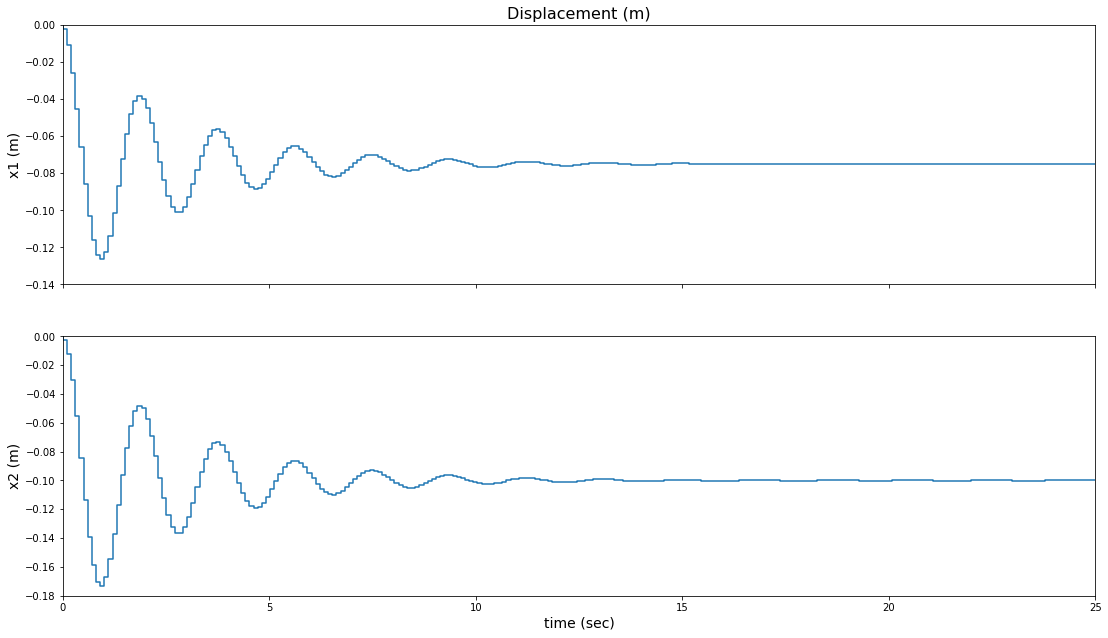

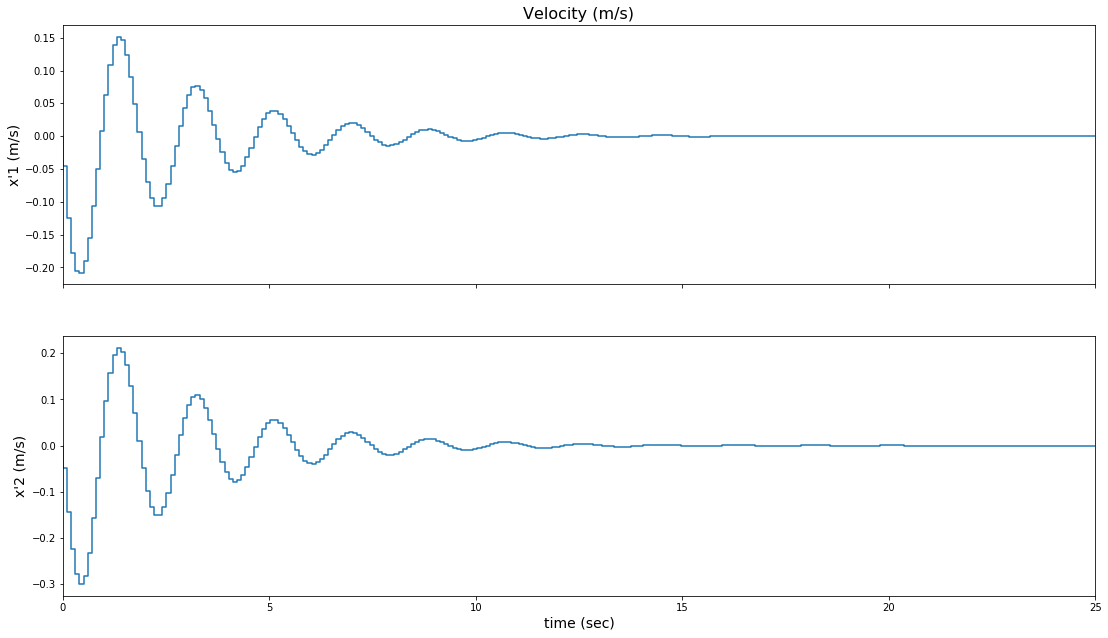

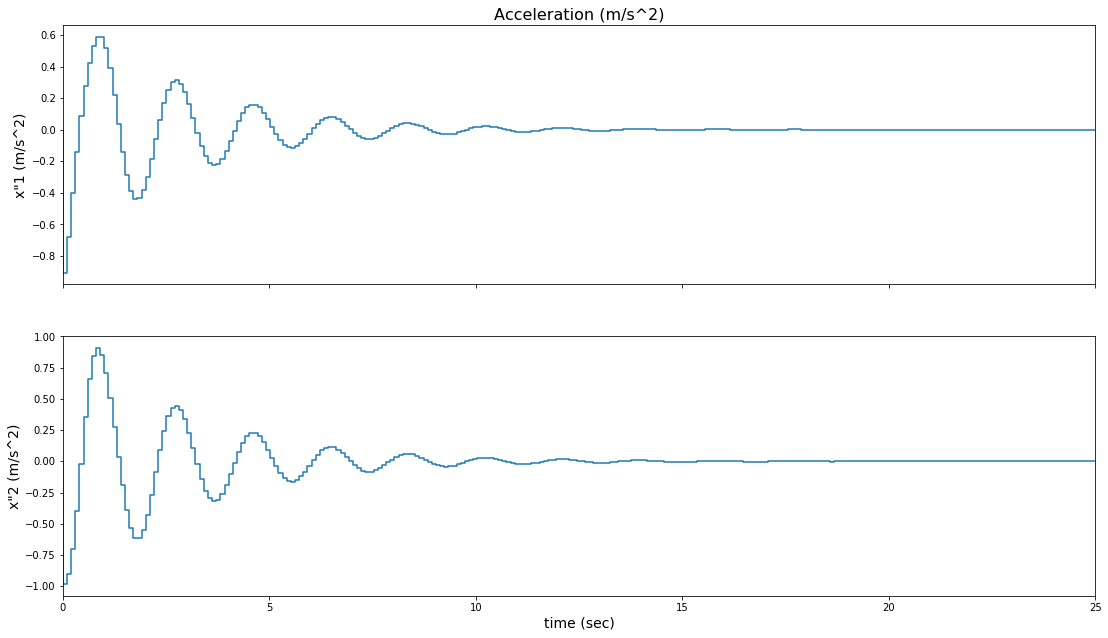

In [280]:
#Uncontrolled sys
from numpy import zeros,dot,atleast_1d
import numpy as np
from scipy import linalg
from matplotlib import pyplot as plt
from math import sqrt
################################################################################


def dampparams(alpha,M,K): #return damping matrix 
    
    beta=0
    w1=sqrt(1-(sqrt(2)/2))*sqrt(K[1,1]/M[1,1]) #first natural freq
    w2=sqrt(1+(sqrt(2)/2))*sqrt(K[1,1]/M[1,1]) #second natural freq
    zeta1 = sqrt((2*sqrt(2)-2)/4)*alpha*sqrt(M[1,1]/K[1,1])+sqrt(2/(2-sqrt(2)))*beta*sqrt(M[1,1]/K[1,1])
    zeta2 = sqrt((2*sqrt(2)+2)/4)*alpha*sqrt(M[1,1]/K[1,1])+sqrt(2/(2+sqrt(2)))*beta*sqrt(M[1,1]/K[1,1])
    phiinv11 = (K[0,0]-w2**2*M[0,0])/(M[0,0]*(w1**2-w2**2))
    phiinv12 = K[0,1]/(M[0,0]*(w1**2-w2**2))
    phiinv21 = -(K[0,0]-w1**2*M[0,0])/(M[0,0]*(w1**2-w2**2))
    phiinv22 = -K[0,1]/(M[0,0]*(w1**2-w2**2))
    phiinv=np.array([[phiinv11,phiinv12],[phiinv21,phiinv22]])
    C1=2*zeta1*w1*(M[0,0]+(M[1,1]*(K[0,0]-w1**2*M[0,0])**2)/K[0,1]**2)
    C2=2*zeta2*w2*(M[0,0]+(M[1,1]*(K[0,0]-w2**2*M[0,0])**2)/K[0,1]**2)
    c = np.matmul(np.matmul(np.transpose(phiinv),np.array([[C1,0],[0,C2]])),phiinv)

    return c


def Newmark_coefficients(dt):
    alpha=0.25
    delta=0.5

    a0=1/(alpha*(dt**2))
    a1=delta/(alpha*dt)
    a2=1/(alpha*dt)
    a3=(1/(2*alpha))-1
    a4=(delta/alpha)-1
    a5=(dt/2)*((delta/alpha)-2)
    a6=dt*(1-delta)
    a7=delta*dt

    return a0,a1,a2,a3,a4,a5,a6,a7

################################################################################

def Newmark_initialize(ndof,a0,a1,M,C,K,NT,DI,VI):

    nlength=len(atleast_1d(M)) 

    KH=zeros((ndof,ndof),float)

    KH=K+a0*M+a1*C

    if(nlength==1):

        U=zeros(NT,float)
        Ud=zeros(NT,float)
        Udd=zeros(NT,float)

        U[0]=DI
        Ud[0]=VI
            
    else:

        U=zeros((ndof,NT),float)
        Ud=zeros((ndof,NT),float)
        Udd=zeros((ndof,NT),float)

        U[:,0]=DI
        Ud[:,0]=VI
    return U,Ud,Udd,KH

def Newmark_force(M,alpha,K,R,VI,DI,dt,Tf,ndof):
    """
    input

    M = mass matrix
    alpha = hyperparameter (for zeta configuration in order to obtain damping matrix)
    K = stiffness matrix
    


    VI = initial velocity
    DI = initial displacement

      dt = time step
      NT = number of time points
    ndof = number of degrees of freedom

    output

      U = displacement
     Ud = velocity
    Udd = acceleration

    """
    
    a0,a1,a2,a3,a4,a5,a6,a7=Newmark_coefficients(dt)
    NT=floor(Tf/dt)
    C=dampparams(alpha,M,K)
    U,Ud,Udd,KH=Newmark_initialize(ndof,a0,a1,M,C,K,NT,DI,VI)
    t=np.linspace(0,Tf,NT)
    f1=zeros(NT,float)
    f2=zeros(NT,float)
    ddxg=zeros(NT,float)
    for i in range (1,NT):

        V1=(a1*U[:,i-1]+a4*Ud[:,i-1]+a5*Udd[:,i-1])
        V2=(a0*U[:,i-1]+a2*Ud[:,i-1]+a3*Udd[:,i-1])

        CV=dot(C,V1)
        MA=dot(M,V2)
        FH=R+MA+CV
        
#  solve for displacements

        if(ndof>1):
            Un = linalg.solve(KH, FH)
        else:
            Un=FH/KH

        Uddn=a0*(Un-U[:,i-1])-a2*Ud[:,i-1]-a3*Udd[:,i-1]
        Udn=Ud[:,i-1]+a6*Udd[:,i-1]+a7*Uddn


        U[:,i]=Un
        Ud[:,i]=Udn
        Udd[:,i]=Uddn
#  delta static
     
    #Displacements
    fig,axs = plt.subplots(2, 1)
    fig.set_size_inches(18.5, 10.5, forward=True)
    axs[0].step(t,U[0,:])
    axs[0].set_title('Displacement (m)',fontsize=16)
    axs[0].set_xlim(0,Tf)
    axs[0].set_ylim(-0.14,0)
    axs[0].set_ylabel('x1 (m)',fontsize=14)
    axs[0].label_outer()
    axs[1].step(t,U[1,:])
    axs[1].set_xlim(0,Tf)
    axs[1].set_ylim(-0.18,0)
    axs[1].set_xlabel('time (sec)',fontsize=14)
    axs[1].set_ylabel('x2 (m)',fontsize=14)
    
    
    #Velocities
    fig1,axs1 = plt.subplots(2, 1)
    fig1.set_size_inches(18.5, 10.5, forward=True)
    axs1[0].step(t,Ud[0,:])
    axs1[0].set_xlim(0,Tf)
    axs1[0].set_title('Velocity (m/s)',fontsize=16)
    axs1[0].set_ylabel("x'1 (m/s)",fontsize=14)
    axs1[0].label_outer()
    axs1[1].step(t,Ud[1,:])
    axs1[1].set_xlim(0,Tf)
    axs1[1].set_ylabel("x'2 (m/s)",fontsize=14)
    axs1[1].set_xlabel('time (sec)',fontsize=14)
    
    #Accelerations
    fig2,axs2 = plt.subplots(2, 1)
    fig2.set_size_inches(18.5, 10.5, forward=True)
    axs2[0].step(t,Udd[0,:])
    axs2[0].set_xlim(0,Tf)
    axs2[0].set_title('Acceleration (m/s^2)',fontsize=16)
    axs2[0].set_ylabel('x"1 (m/s^2)',fontsize=14)
    axs2[0].label_outer()
    axs2[1].step(t,Udd[1,:])
    axs2[1].set_xlim(0,Tf)
    axs2[1].set_ylabel('x"2 (m/s^2)',fontsize=14)
    axs2[1].set_xlabel('time (sec)',fontsize=14)
    
    return ddxg
f1=0
f2=0
ddxg=1
M=np.array([[100,0],[0,50]])
K=np.array([[4000,-2000],[-2000,2000]])
R=np.array([f1-M[0,0]*ddxg,f2-M[1,1]*ddxg])
resp=Newmark_force(M,1.5,K,R,0,0,0.1,25,2)
resp[0]



In [256]:
np.shape(resp[0])

(2, 250)

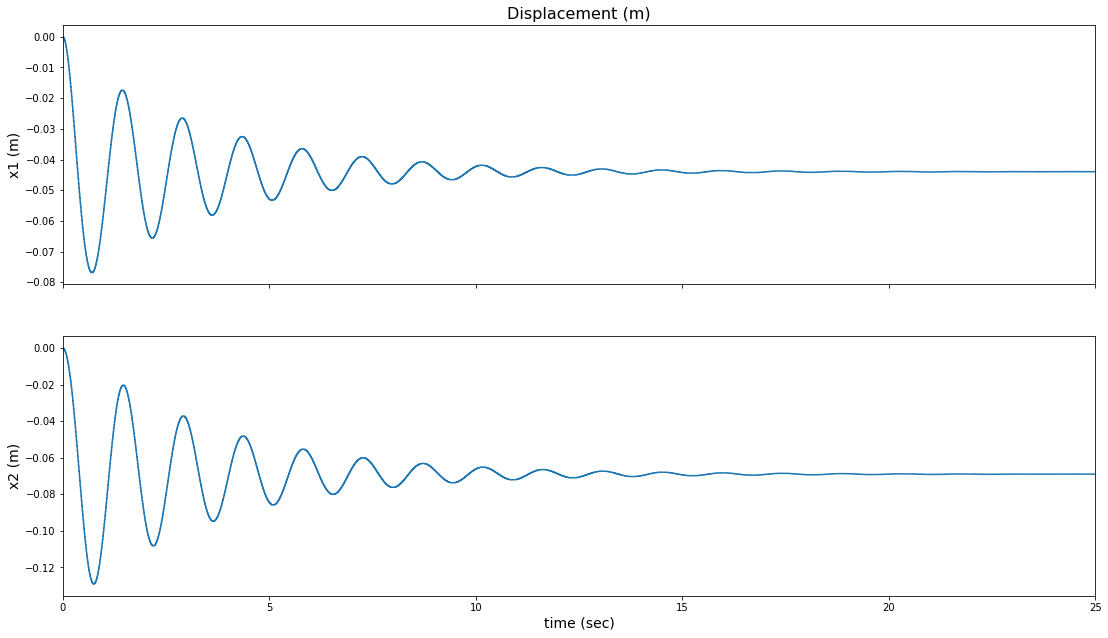

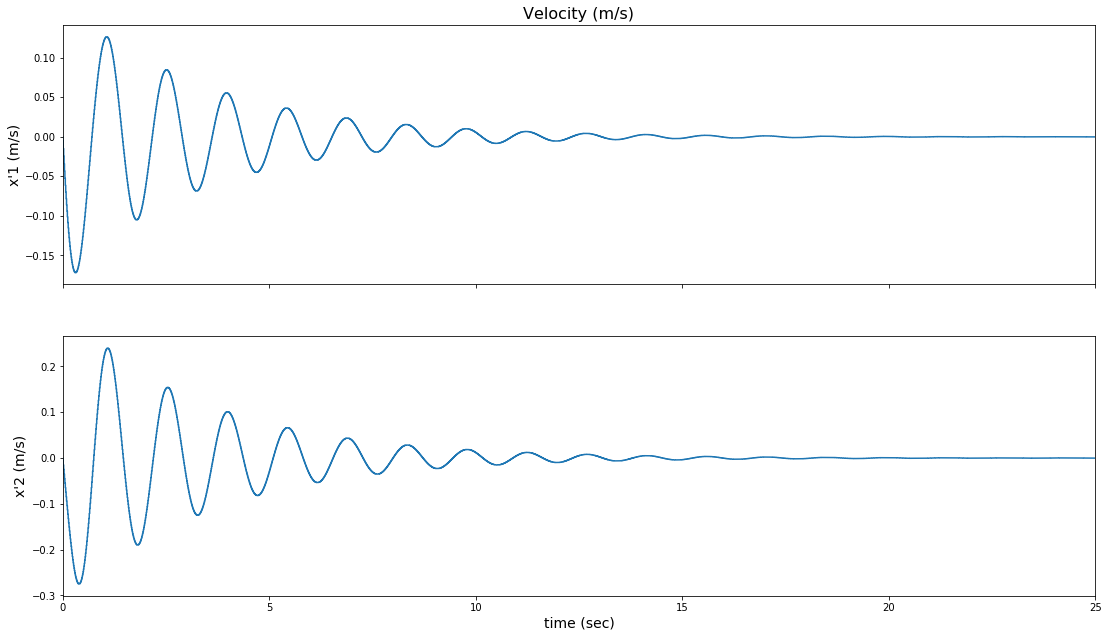

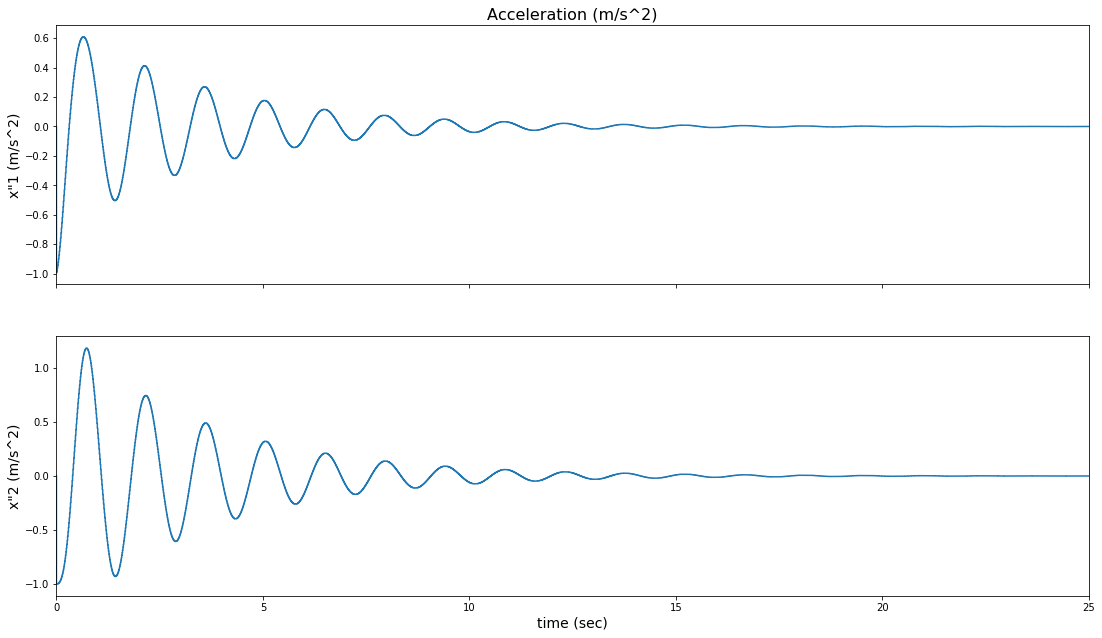

In [260]:
#########P controller

from numpy import zeros,dot,atleast_1d
import numpy as np
from scipy import linalg
from matplotlib import pyplot as plt
from math import sqrt
################################################################################


def dampparams(alpha,M,K): #return damping matrix 
    
    beta=0
    w1=sqrt(1-(sqrt(2)/2))*sqrt(K[1,1]/M[1,1]) #first natural freq
    w2=sqrt(1+(sqrt(2)/2))*sqrt(K[1,1]/M[1,1]) #second natural freq
    zeta1 = sqrt((2*sqrt(2)-2)/4)*alpha*sqrt(M[1,1]/K[1,1])+sqrt(2/(2-sqrt(2)))*beta*sqrt(M[1,1]/K[1,1])
    zeta2 = sqrt((2*sqrt(2)+2)/4)*alpha*sqrt(M[1,1]/K[1,1])+sqrt(2/(2+sqrt(2)))*beta*sqrt(M[1,1]/K[1,1])
    phiinv11 = (K[0,0]-w2**2*M[0,0])/(M[0,0]*(w1**2-w2**2))
    phiinv12 = K[0,1]/(M[0,0]*(w1**2-w2**2))
    phiinv21 = -(K[0,0]-w1**2*M[0,0])/(M[0,0]*(w1**2-w2**2))
    phiinv22 = -K[0,1]/(M[0,0]*(w1**2-w2**2))
    phiinv=np.array([[phiinv11,phiinv12],[phiinv21,phiinv22]])
    C1=2*zeta1*w1*(M[0,0]+(M[1,1]*(K[0,0]-w1**2*M[0,0])**2)/K[0,1]**2)
    C2=2*zeta2*w2*(M[0,0]+(M[1,1]*(K[0,0]-w2**2*M[0,0])**2)/K[0,1]**2)
    c = np.matmul(np.matmul(np.transpose(phiinv),np.array([[C1,0],[0,C2]])),phiinv)

    return c


def Newmark_coefficients(dt):
    alpha=0.25
    delta=0.5

    a0=1/(alpha*(dt**2))
    a1=delta/(alpha*dt)
    a2=1/(alpha*dt)
    a3=(1/(2*alpha))-1
    a4=(delta/alpha)-1
    a5=(dt/2)*((delta/alpha)-2)
    a6=dt*(1-delta)
    a7=delta*dt

    return a0,a1,a2,a3,a4,a5,a6,a7

################################################################################

def Newmark_initialize(ndof,a0,a1,M,C,K,NT,DI,VI):

    nlength=len(atleast_1d(M)) 

    KH=zeros((ndof,ndof),float)

    KH=K+a0*M+a1*C

    if(nlength==1):

        U=zeros(NT,float)
        Ud=zeros(NT,float)
        Udd=zeros(NT,float)

        U[0]=DI
        Ud[0]=VI
            
    else:

        U=zeros((ndof,NT),float)
        Ud=zeros((ndof,NT),float)
        Udd=zeros((ndof,NT),float)

        U[:,0]=DI
        Ud[:,0]=VI
    return U,Ud,Udd,KH

def Newmark_force(M,alpha,K,R,r,kp,VI,DI,dt,Tf,ndof,ddxg):
    """
    input

    M = mass matrix
    alpha = hyperparameter (for zeta configuration in order to obtain damping matrix)
    K = stiffness matrix
    


    VI = initial velocity
    DI = initial displacement

      dt = time step
      NT = number of time points
    ndof = number of degrees of freedom

    output

      U = displacement
     Ud = velocity
    Udd = acceleration

    """
    
    a0,a1,a2,a3,a4,a5,a6,a7=Newmark_coefficients(dt)
    NT=floor(Tf/dt)
    C=dampparams(alpha,M,K)
    U,Ud,Udd,KH=Newmark_initialize(ndof,a0,a1,M,C,K,NT,DI,VI)
    t=np.linspace(0,Tf,NT)
    e=0
    f2=0
    for i in range (1,NT):
        e = r-U[1,i-1];
        f1 = kp*e;
        R=np.array([f1-M[0,0]*ddxg,f2-M[1,1]*ddxg])
        V1=(a1*U[:,i-1]+a4*Ud[:,i-1]+a5*Udd[:,i-1])
        V2=(a0*U[:,i-1]+a2*Ud[:,i-1]+a3*Udd[:,i-1])
        CV=dot(C,V1)
        MA=dot(M,V2)
        FH=R+MA+CV

#  solve for displacements

        if(ndof>1):
            Un = linalg.solve(KH, FH)
        else:
            Un=FH/KH

        Uddn=a0*(Un-U[:,i-1])-a2*Ud[:,i-1]-a3*Udd[:,i-1]
        Udn=Ud[:,i-1]+a6*Udd[:,i-1]+a7*Uddn


        U[:,i]=Un
        Ud[:,i]=Udn
        Udd[:,i]=Uddn
        
#  delta static
     
    #Displacements
    fig,axs = plt.subplots(2, 1)
    fig.set_size_inches(18.5, 10.5, forward=True)
    axs[0].step(t,U[0,:])
    axs[0].set_title('Displacement (m)',fontsize=16)
    axs[0].set_xlim(0,Tf)
    axs[0].set_ylabel('x1 (m)',fontsize=14)
    axs[0].label_outer()
    axs[1].step(t,U[1,:])
    axs[1].set_xlim(0,Tf)
    axs[1].set_xlabel('time (sec)',fontsize=14)
    axs[1].set_ylabel('x2 (m)',fontsize=14)
    
    
    #Velocities
    fig1,axs1 = plt.subplots(2, 1)
    fig1.set_size_inches(18.5, 10.5, forward=True)
    axs1[0].step(t,Ud[0,:])
    axs1[0].set_xlim(0,Tf)
    axs1[0].set_title('Velocity (m/s)',fontsize=16)
    axs1[0].set_ylabel("x'1 (m/s)",fontsize=14)
    axs1[0].label_outer()
    axs1[1].step(t,Ud[1,:])
    axs1[1].set_xlim(0,Tf)
    axs1[1].set_ylabel("x'2 (m/s)",fontsize=14)
    axs1[1].set_xlabel('time (sec)',fontsize=14)
    
    #Accelerations
    fig2,axs2 = plt.subplots(2, 1)
    fig2.set_size_inches(18.5, 10.5, forward=True)
    axs2[0].step(t,Udd[0,:])
    axs2[0].set_xlim(0,Tf)
    axs2[0].set_title('Acceleration (m/s^2)',fontsize=16)
    axs2[0].set_ylabel('x"1 (m/s^2)',fontsize=14)
    axs2[0].label_outer()
    axs2[1].step(t,Udd[1,:])
    axs2[1].set_xlim(0,Tf)
    axs2[1].set_ylabel('x"2 (m/s^2)',fontsize=14)
    axs2[1].set_xlabel('time (sec)',fontsize=14)

    return U,Ud,Udd,NT,t,C
f1=0
f2=0
ddxg=1
M=np.array([[100,0],[0,50]])
K=np.array([[4000,-2000],[-2000,2000]])
R=np.array([f1-M[0,0]*ddxg,f2-M[1,1]*ddxg])
kp=900
r=0
resp=Newmark_force(M,1.5,K,R,r,kp,0,0,0.01,25,2,ddxg)




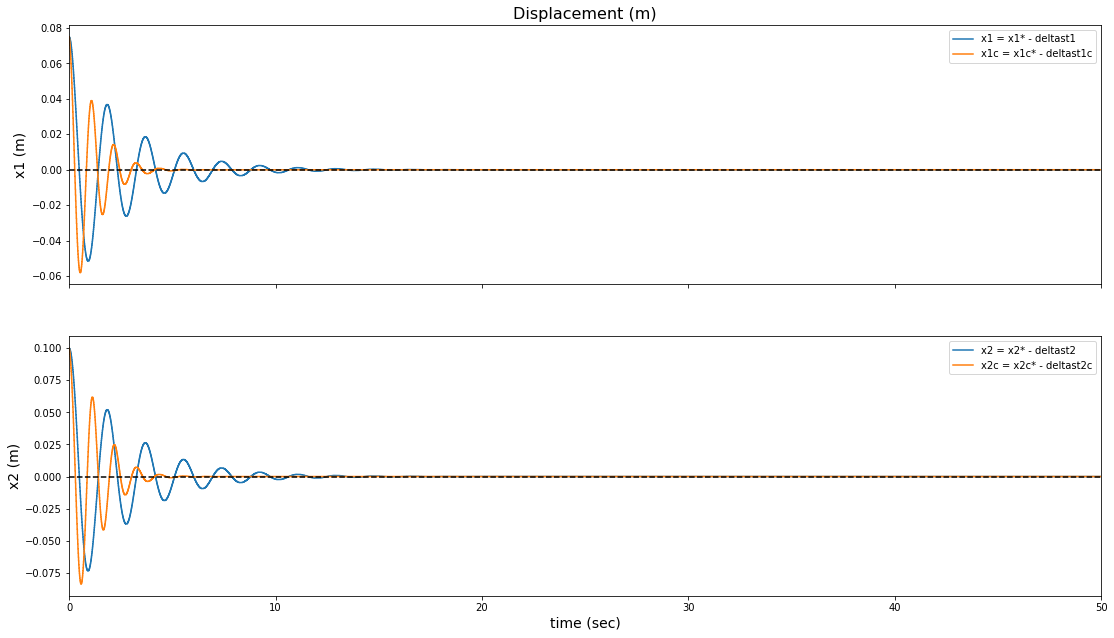

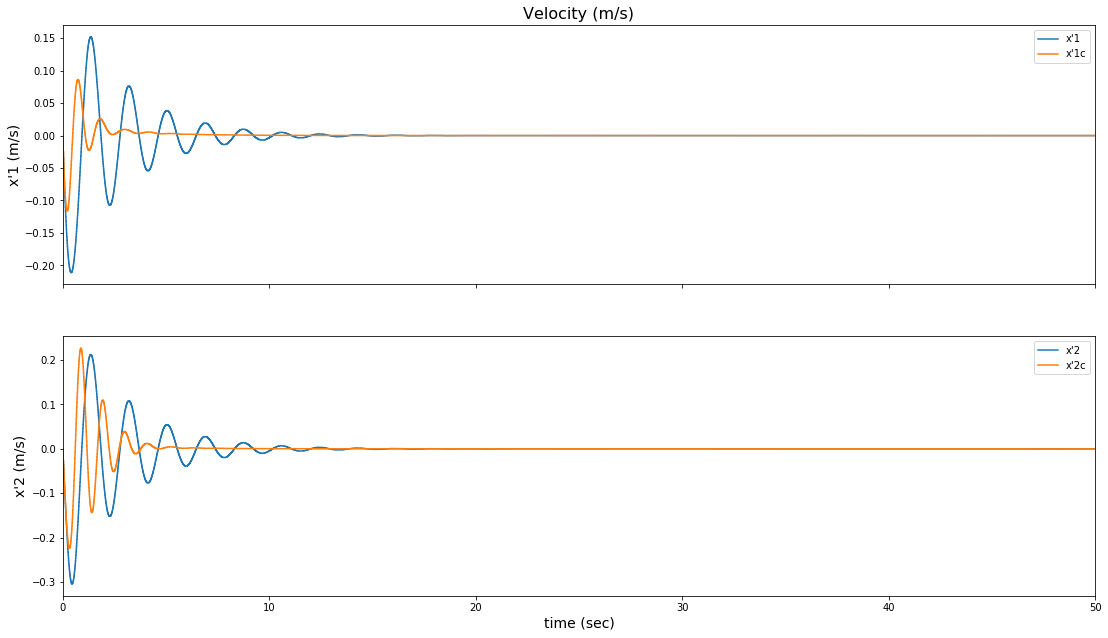

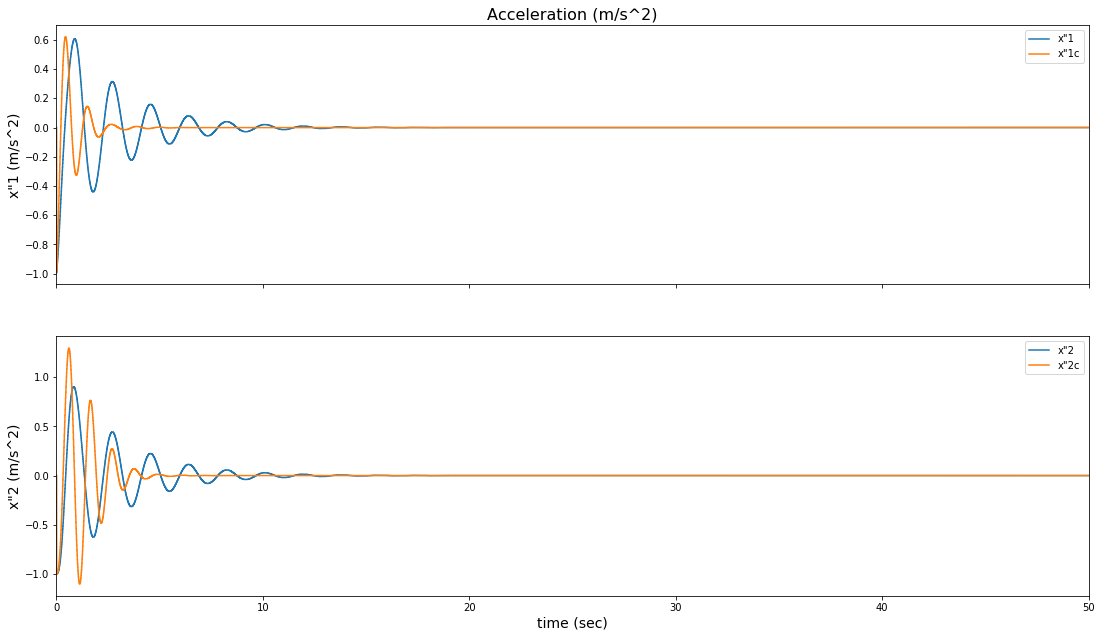

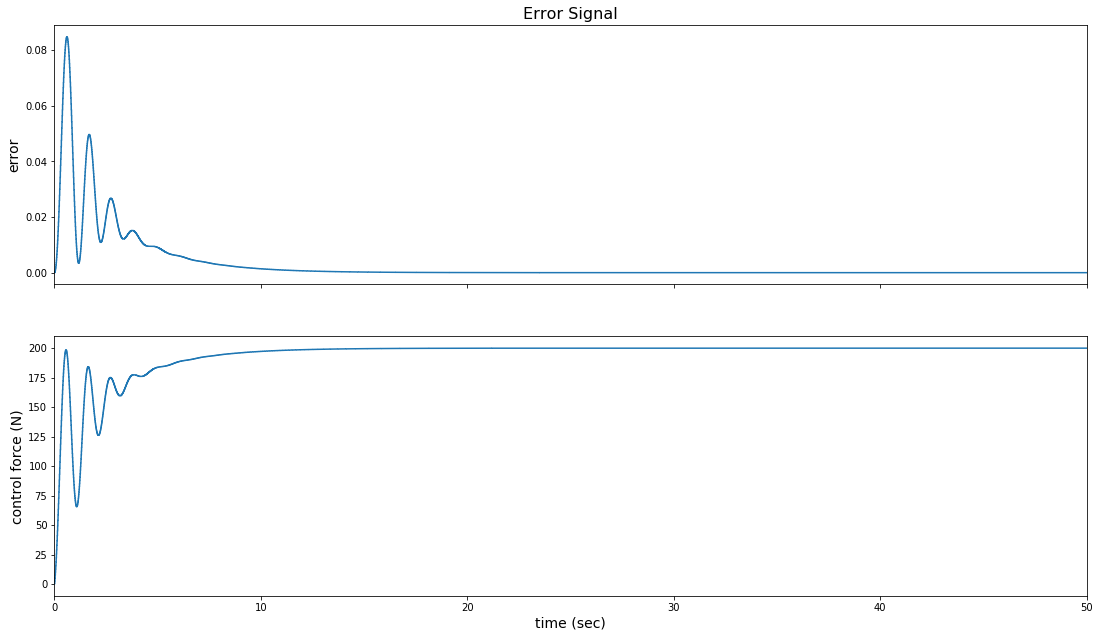

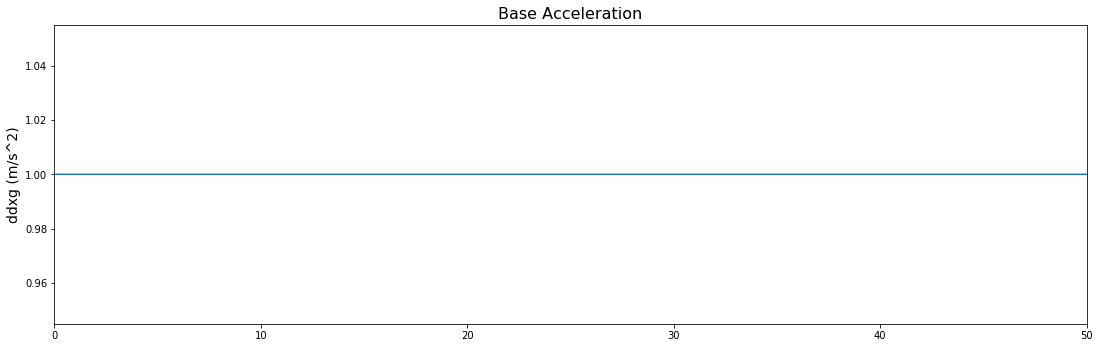

In [69]:
#########PID controller + Uncontrolled system

from numpy import zeros,dot,atleast_1d
import numpy as np
from scipy import linalg
from matplotlib import pyplot as plt
from math import sqrt
import time
import numpy as np
import shamirproc
import shamirscheme as sss
from matplotlib import pyplot as plt
from scipy.interpolate import interp1d
from tabulate import tabulate
from decimal import Decimal
################################################################################


def dampparams(alpha,M,K): #return damping matrix 
    
    beta=0
    w1=sqrt(1-(sqrt(2)/2))*sqrt(K[1,1]/M[1,1]) #first natural freq
    w2=sqrt(1+(sqrt(2)/2))*sqrt(K[1,1]/M[1,1]) #second natural freq
    zeta1 = sqrt((2*sqrt(2)-2)/4)*alpha*sqrt(M[1,1]/K[1,1])+sqrt(2/(2-sqrt(2)))*beta*sqrt(M[1,1]/K[1,1])
    zeta2 = sqrt((2*sqrt(2)+2)/4)*alpha*sqrt(M[1,1]/K[1,1])+sqrt(2/(2+sqrt(2)))*beta*sqrt(M[1,1]/K[1,1])
    phiinv11 = (K[0,0]-w2**2*M[0,0])/(M[0,0]*(w1**2-w2**2))
    phiinv12 = K[0,1]/(M[0,0]*(w1**2-w2**2))
    phiinv21 = -(K[0,0]-w1**2*M[0,0])/(M[0,0]*(w1**2-w2**2))
    phiinv22 = -K[0,1]/(M[0,0]*(w1**2-w2**2))
    phiinv=np.array([[phiinv11,phiinv12],[phiinv21,phiinv22]])
    C1=2*zeta1*w1*(M[0,0]+(M[1,1]*(K[0,0]-w1**2*M[0,0])**2)/K[0,1]**2)
    C2=2*zeta2*w2*(M[0,0]+(M[1,1]*(K[0,0]-w2**2*M[0,0])**2)/K[0,1]**2)
    c = np.matmul(np.matmul(np.transpose(phiinv),np.array([[C1,0],[0,C2]])),phiinv)

    return c


def Newmark_coefficients(dt):
    alpha=0.25
    delta=0.5

    a0=1/(alpha*(dt**2))
    a1=delta/(alpha*dt)
    a2=1/(alpha*dt)
    a3=(1/(2*alpha))-1
    a4=(delta/alpha)-1
    a5=(dt/2)*((delta/alpha)-2)
    a6=dt*(1-delta)
    a7=delta*dt

    return a0,a1,a2,a3,a4,a5,a6,a7

################################################################################

def Newmark_initialize(ndof,a0,a1,M,C,K,NT,DI,VI):
    
    nlength=len(atleast_1d(M)) 

    KH=zeros((ndof,ndof),float)

    KH=K+a0*M+a1*C

    if(nlength==1):

        U=zeros(NT,float)
        Ud=zeros(NT,float)
        Udd=zeros(NT,float)

        U[0]=DI
        Ud[0]=VI
            
    else:

        U=zeros((ndof,NT),float)
        Ud=zeros((ndof,NT),float)
        Udd=zeros((ndof,NT),float)

        U[:,0]=DI
        Ud[:,0]=VI
    return U,Ud,Udd,KH

def Newmark_PID(M,alpha,K,R,r,kp,ki,kd,VI,DI,dt,Tf,ndof,ddxg):
    """
    input

    M = mass matrix
    alpha = hyperparameter (for zeta configuration in order to obtain damping matrix)
    K = stiffness matrix
    


    VI = initial velocity
    DI = initial displacement

      dt = time step
      NT = number of time points
    ndof = number of degrees of freedom

    output

      U = displacement
     Ud = velocity
    Udd = acceleration

    """
#uncontrolled sys    
    a0,a1,a2,a3,a4,a5,a6,a7=Newmark_coefficients(dt)
    NT=floor(Tf/dt)
    C=dampparams(alpha,M,K)
    U,Ud,Udd,KH=Newmark_initialize(ndof,a0,a1,M,C,K,NT,DI,VI)
    t=np.linspace(0,Tf,NT)
    f1=0
    f2=0
    
    for i in range (1,NT):
        R=np.array([f1-M[0,0]*ddxg,f2-M[1,1]*ddxg])
        V1=(a1*U[:,i-1]+a4*Ud[:,i-1]+a5*Udd[:,i-1])
        V2=(a0*U[:,i-1]+a2*Ud[:,i-1]+a3*Udd[:,i-1])
        CV=dot(C,V1)
        MA=dot(M,V2)
        FH=R+MA+CV

#  solve for displacements

        if(ndof>1):
            Un = linalg.solve(KH, FH)
        else:
            Un=FH/KH

        Uddn=a0*(Un-U[:,i-1])-a2*Ud[:,i-1]-a3*Udd[:,i-1]
        Udn=Ud[:,i-1]+a6*Udd[:,i-1]+a7*Uddn


        U[:,i]=Un
        Ud[:,i]=Udn
        Udd[:,i]=Uddn
        
#### control system
    e=0
    f2c=0
    f1c=0
    integral_prev=0
    eprev = 0
    error=[]
    f1cont=[]
    error.append(0)
    f1cont.append(0)
    DDxg=[]
    DDxg.append(ddxg)
    deltast1c=[]
    deltast2c=[]
    deltast1c.append((f1c+f2c-3*M[1,1]*ddxg)/K[1,1])
    deltast2c.append((f1c+2*f2c-4*M[1,1]*ddxg)/K[1,1]);
    Uc,Udc,Uddc,KHc=Newmark_initialize(ndof,a0,a1,M,C,K,NT,DI,VI)
    for i in range (1,NT):
        e = r-Uc[1,i-1]; #sensor is located on second mass
        integeral = integral_prev + e*dt
        f1c = kp*e + ki*integeral + kd*(error[i-2]-4*eprev+3*e)/(2*dt)
        Rc=np.array([f1c-M[0,0]*ddxg,f2c-M[1,1]*ddxg])
        V1c=(a1*Uc[:,i-1]+a4*Udc[:,i-1]+a5*Uddc[:,i-1])
        V2c=(a0*Uc[:,i-1]+a2*Udc[:,i-1]+a3*Uddc[:,i-1])
        CVc=dot(C,V1c)
        MAc=dot(M,V2c)
        FHc=Rc+MAc+CVc

#  solve for displacements

        if(ndof>1):
            Unc = linalg.solve(KHc, FHc)
        else:
            Unc=FHc/KHc

        Uddnc=a0*(Unc-Uc[:,i-1])-a2*Udc[:,i-1]-a3*Uddc[:,i-1]
        Udnc=Udc[:,i-1]+a6*Uddc[:,i-1]+a7*Uddnc

        eprev = e;
        integral_prev = integeral
        Uc[:,i]=Unc
        Udc[:,i]=Udnc
        Uddc[:,i]=Uddnc
        error.append(e)
        f1cont.append(f1c)
        deltast1c.append((f1c+f2c-3*M[1,1]*ddxg)/K[1,1])
        deltast2c.append((f1c+2*f2c-4*M[1,1]*ddxg)/K[1,1])
        DDxg.append(ddxg)
        
        
#  delta static
    deltast1 = (f1+f2-3*M[1,1]*ddxg)/K[1,1]
    deltast2 = (f1+2*f2-4*M[1,1]*ddxg)/K[1,1]
    
    #Displacements
    fig,axs = plt.subplots(2, 1)
    fig.set_size_inches(18.5, 10.5, forward=True)
    axs[0].step(t,U[0,:]-deltast1)
    axs[0].step(t,Uc[0,:]-deltast1c)
    axs[0].axhline(y = r, color = 'black', linestyle = '--')
    axs[0].set_title('Displacement (m)',fontsize=16)
    axs[0].set_xlim(0,Tf)
    axs[0].legend(['x1 = x1* - deltast1','x1c = x1c* - deltast1c'])
    axs[0].set_ylabel('x1 (m)',fontsize=14)
    axs[0].label_outer()
    axs[1].step(t,U[1,:]-deltast2)
    axs[1].step(t,Uc[1,:]-deltast2c)
    axs[1].axhline(y = r, color = 'black', linestyle = '--')
    axs[1].set_xlim(0,Tf)
    axs[1].set_xlabel('time (sec)',fontsize=14)
    axs[1].set_ylabel('x2 (m)',fontsize=14)
    axs[1].legend(['x2 = x2* - deltast2','x2c = x2c* - deltast2c'])
    
    
    #Velocities
    fig1,axs1 = plt.subplots(2, 1)
    fig1.set_size_inches(18.5, 10.5, forward=True)
    axs1[0].step(t,Ud[0,:])
    axs1[0].step(t,Udc[0,:])
    axs1[0].set_xlim(0,Tf)
    axs1[0].set_title('Velocity (m/s)',fontsize=16)
    axs1[0].set_ylabel("x'1 (m/s)",fontsize=14)
    axs1[0].legend(["x'1","x'1c"])
    axs1[0].label_outer()
    axs1[1].step(t,Ud[1,:])
    axs1[1].step(t,Udc[1,:])
    axs1[1].set_xlim(0,Tf)
    axs1[1].set_ylabel("x'2 (m/s)",fontsize=14)
    axs1[1].set_xlabel('time (sec)',fontsize=14)
    axs1[1].legend(["x'2","x'2c"])
    
    #Accelerations
    fig2,axs2 = plt.subplots(2, 1)
    fig2.set_size_inches(18.5, 10.5, forward=True)
    axs2[0].step(t,Udd[0,:])
    axs2[0].step(t,Uddc[0,:])
    axs2[0].set_xlim(0,Tf)
    axs2[0].set_title('Acceleration (m/s^2)',fontsize=16)
    axs2[0].set_ylabel('x"1 (m/s^2)',fontsize=14)
    axs2[0].legend(['x"1','x"1c'])
    axs2[0].label_outer()
    axs2[1].step(t,Udd[1,:])
    axs2[1].step(t,Uddc[1,:])
    axs2[1].set_xlim(0,Tf)
    axs2[1].set_ylabel('x"2 (m/s^2)',fontsize=14)
    axs2[1].set_xlabel('time (sec)',fontsize=14)
    axs2[1].legend(['x"2','x"2c'])
    
    #Error and control force
    fig3,axs3 = plt.subplots(2, 1)
    fig3.set_size_inches(18.5, 10.5, forward=True)
    axs3[0].step(t,error)
    axs3[0].set_xlim(0,Tf)
    axs3[0].set_title('Error Signal',fontsize=16)
    axs3[0].set_ylabel('error',fontsize=14)
    axs3[0].label_outer()
    axs3[1].step(t,f1cont)
    axs3[1].set_xlim(0,Tf)
    axs3[1].set_ylabel('control force (N)',fontsize=14)
    axs3[1].set_xlabel('time (sec)',fontsize=14)
    
    #dsturbances
    fig4,axs4 = plt.subplots(1, 1)
    fig4.set_size_inches(18.5, 5.5, forward=True)
    axs4.step(t,DDxg)
    axs4.set_xlim(0,Tf)
    axs4.set_title('Base Acceleration',fontsize=16)
    axs4.set_ylabel('ddxg (m/s^2)',fontsize=14)
    axs4.label_outer()
    return U,Ud,Udd,NT,t,C
f1=0
f2=0
ddxg=1
M=np.array([[100,0],[0,50]])
K=np.array([[4000,-2000],[-2000,2000]])
R=np.array([f1-M[0,0]*ddxg,f2-M[1,1]*ddxg])
kp = 1.9e+03#100
ki = 1.39e+03#200
kd = 178 #200 
r=0 #refference input
resp=Newmark_PID(M,1.5,K,R,r,kp,ki,kd,0,0,0.01,50,2,ddxg)




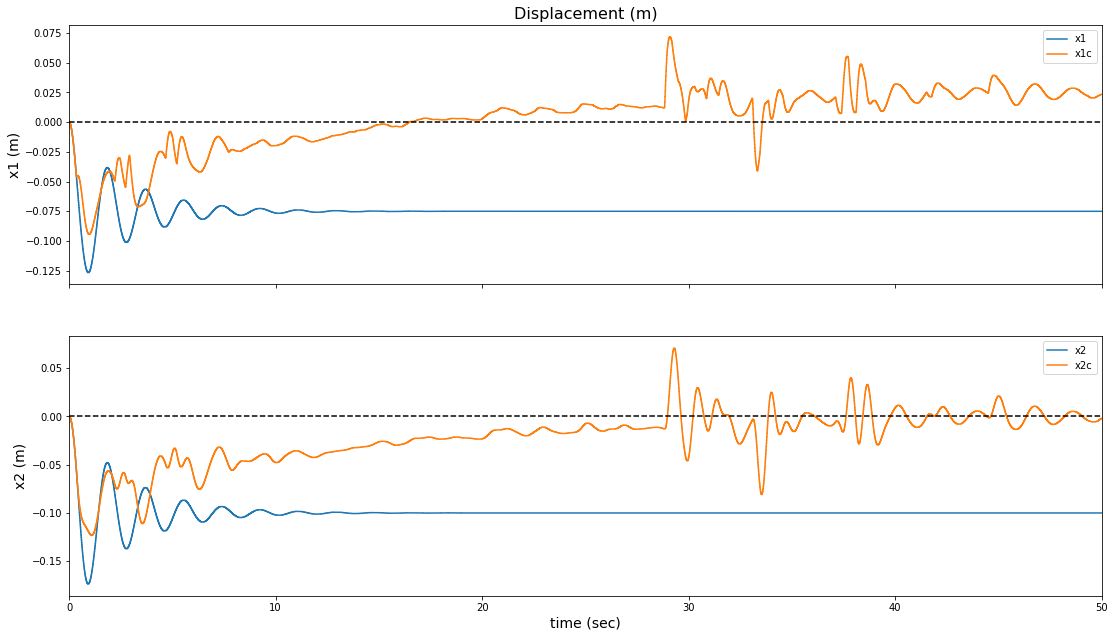

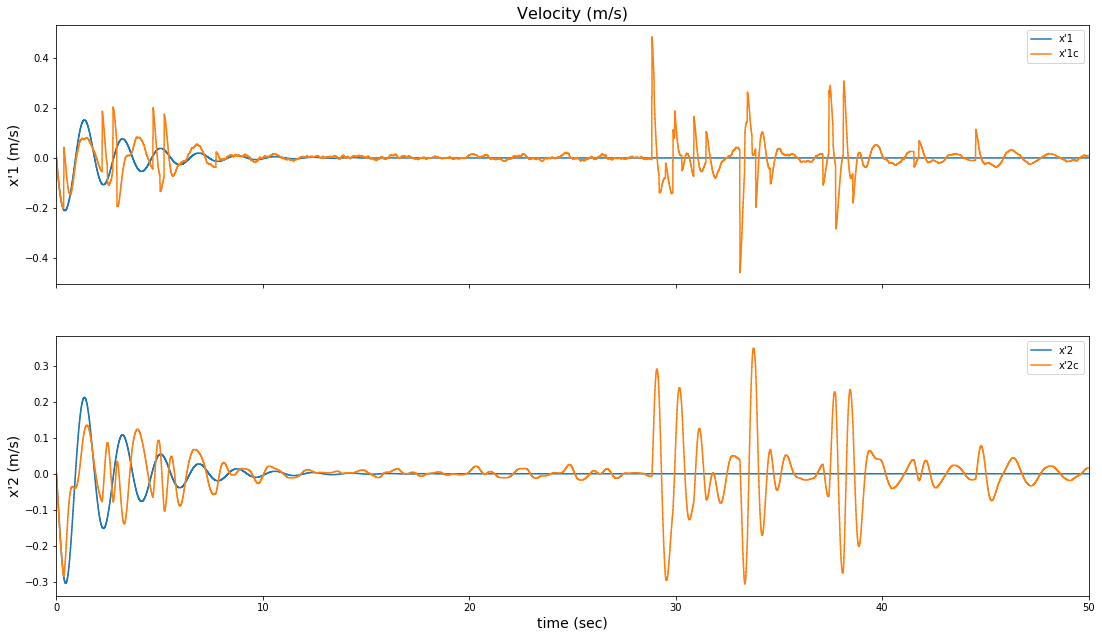

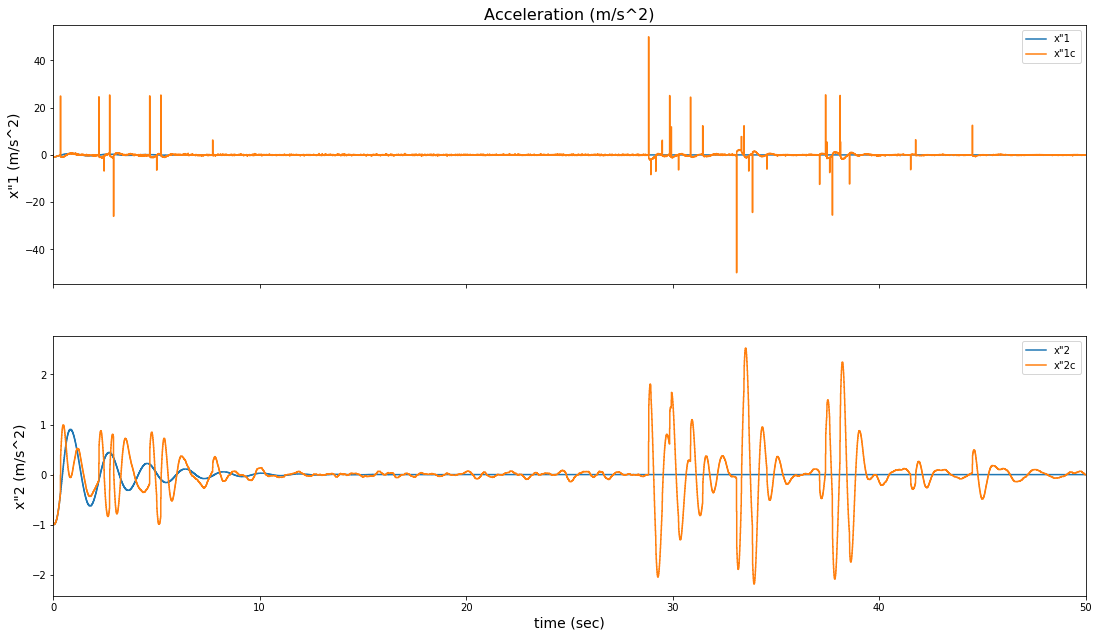

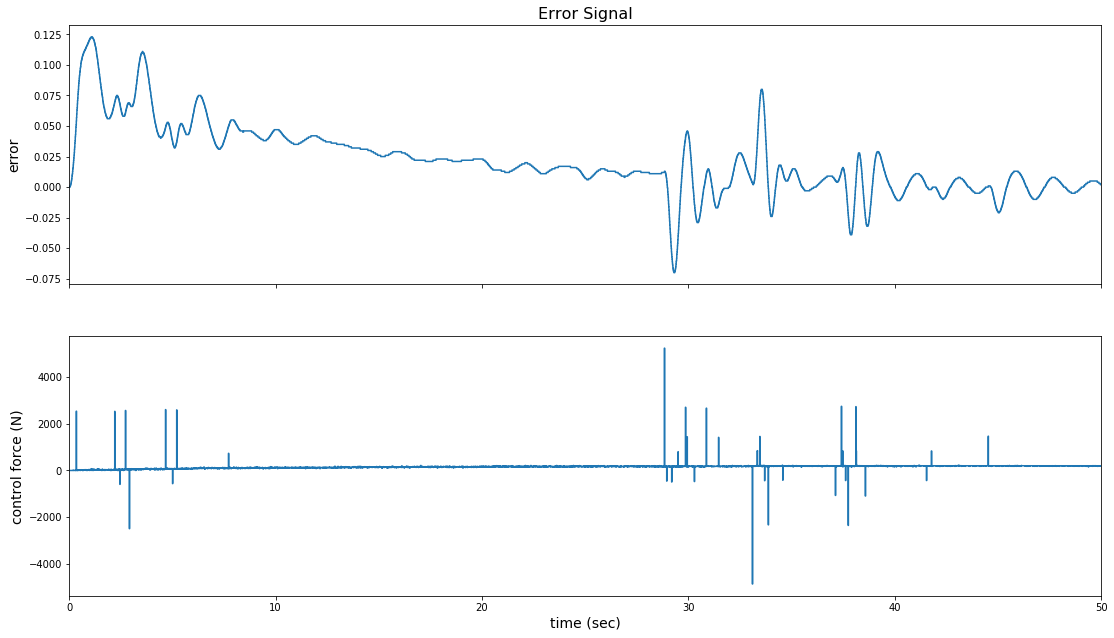

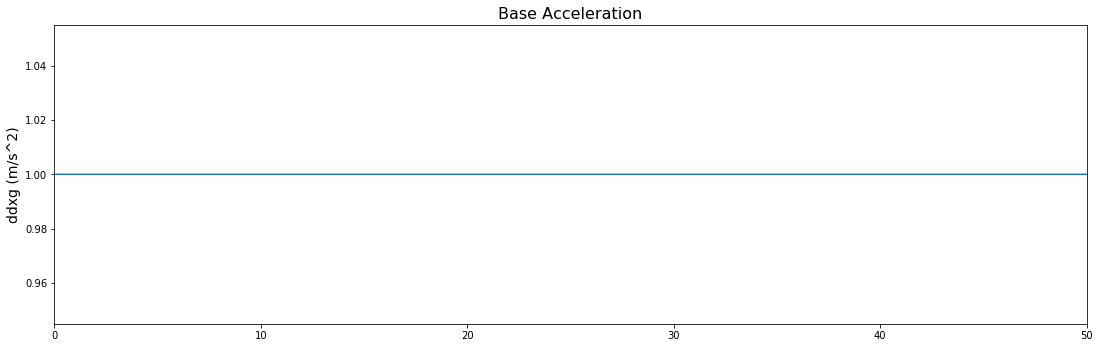

In [44]:
############SECURE CONTROLLED SYS
#########PID controller + Uncontrolled system

from numpy import zeros,dot,atleast_1d
import numpy as np
from scipy import linalg
from matplotlib import pyplot as plt
from math import sqrt
import time
import numpy as np
import shamirproc
import shamirscheme as sss
from matplotlib import pyplot as plt
from scipy.interpolate import interp1d
from tabulate import tabulate
from decimal import Decimal
################################################################################


def dampparams(alpha,M,K): #return damping matrix 
    
    beta=0
    w1=sqrt(1-(sqrt(2)/2))*sqrt(K[1,1]/M[1,1]) #first natural freq
    w2=sqrt(1+(sqrt(2)/2))*sqrt(K[1,1]/M[1,1]) #second natural freq
    zeta1 = sqrt((2*sqrt(2)-2)/4)*alpha*sqrt(M[1,1]/K[1,1])+sqrt(2/(2-sqrt(2)))*beta*sqrt(M[1,1]/K[1,1])
    zeta2 = sqrt((2*sqrt(2)+2)/4)*alpha*sqrt(M[1,1]/K[1,1])+sqrt(2/(2+sqrt(2)))*beta*sqrt(M[1,1]/K[1,1])
    phiinv11 = (K[0,0]-w2**2*M[0,0])/(M[0,0]*(w1**2-w2**2))
    phiinv12 = K[0,1]/(M[0,0]*(w1**2-w2**2))
    phiinv21 = -(K[0,0]-w1**2*M[0,0])/(M[0,0]*(w1**2-w2**2))
    phiinv22 = -K[0,1]/(M[0,0]*(w1**2-w2**2))
    phiinv=np.array([[phiinv11,phiinv12],[phiinv21,phiinv22]])
    C1=2*zeta1*w1*(M[0,0]+(M[1,1]*(K[0,0]-w1**2*M[0,0])**2)/K[0,1]**2)
    C2=2*zeta2*w2*(M[0,0]+(M[1,1]*(K[0,0]-w2**2*M[0,0])**2)/K[0,1]**2)
    c = np.matmul(np.matmul(np.transpose(phiinv),np.array([[C1,0],[0,C2]])),phiinv)

    return c


def Newmark_coefficients(dt):
    alpha=0.25
    delta=0.5

    a0=1/(alpha*(dt**2))
    a1=delta/(alpha*dt)
    a2=1/(alpha*dt)
    a3=(1/(2*alpha))-1
    a4=(delta/alpha)-1
    a5=(dt/2)*((delta/alpha)-2)
    a6=dt*(1-delta)
    a7=delta*dt

    return a0,a1,a2,a3,a4,a5,a6,a7

################################################################################

def Newmark_initialize(ndof,a0,a1,M,C,K,NT,DI,VI):
    
    nlength=len(atleast_1d(M)) 

    KH=zeros((ndof,ndof),float)

    KH=K+a0*M+a1*C

    if(nlength==1):

        U=zeros(NT,float)
        Ud=zeros(NT,float)
        Udd=zeros(NT,float)

        U[0]=DI
        Ud[0]=VI
            
    else:

        U=zeros((ndof,NT),float)
        Ud=zeros((ndof,NT),float)
        Udd=zeros((ndof,NT),float)

        U[:,0]=DI
        Ud[:,0]=VI
    return U,Ud,Udd,KH

def Newmark_PID(F,server,t,scale,M,alpha,K,R,r,kp,ki,kd,VI,DI,dt,Tf,ndof,ddxg):
    """
    input

    M = mass matrix
    alpha = hyperparameter (for zeta configuration in order to obtain damping matrix)
    K = stiffness matrix
    


    VI = initial velocity
    DI = initial displacement

      dt = time step
      NT = number of time points
    ndof = number of degrees of freedom

    output

      U = displacement
     Ud = velocity
    Udd = acceleration

    """
#uncontrolled sys    
    a0,a1,a2,a3,a4,a5,a6,a7=Newmark_coefficients(dt)
    NT=floor(Tf/dt)
    C=dampparams(alpha,M,K)
    U,Ud,Udd,KH=Newmark_initialize(ndof,a0,a1,M,C,K,NT,DI,VI)
    taim=np.linspace(0,Tf,NT)
    f1=0
    f2=0
    
    for i in range (1,NT):
        R=np.array([f1-M[0,0]*ddxg,f2-M[1,1]*ddxg])
        V1=(a1*U[:,i-1]+a4*Ud[:,i-1]+a5*Udd[:,i-1])
        V2=(a0*U[:,i-1]+a2*Ud[:,i-1]+a3*Udd[:,i-1])
        CV=dot(C,V1)
        MA=dot(M,V2)
        FH=R+MA+CV

#  solve for displacements

        if(ndof>1):
            Un = linalg.solve(KH, FH)
        else:
            Un=FH/KH

        Uddn=a0*(Un-U[:,i-1])-a2*Ud[:,i-1]-a3*Udd[:,i-1]
        Udn=Ud[:,i-1]+a6*Udd[:,i-1]+a7*Uddn


        U[:,i]=Un
        Ud[:,i]=Udn
        Udd[:,i]=Uddn
        
#### control system
    es=sss.share(F,0,t,server,scale)
    f2cs=0
    f1cs=0
    integral_prevs=sss.share(F,0,t,server,scale)
    eprevs = sss.share(F,0,t,server,scale)
    errors=[]
    f1conts=[]
    errors.append(0)
    f1conts.append(0)
    DDxgs=[]
    DDxgs.append(ddxg)
    deltast1cs=[]
    deltast2cs=[]
    deltast1cs.append((f1cs+f2cs-3*M[1,1]*ddxg)/K[1,1])
    deltast2cs.append((f1cs+2*f2cs-4*M[1,1]*ddxg)/K[1,1])
    Ucs,Udcs,Uddcs,KHcs=Newmark_initialize(ndof,a0,a1,M,C,K,NT,DI,VI)
    rs = sss.share(F,r,t,server,scale)
    Ucs2 = sss.share(F,-Ucs[1,0],t,server,scale)
    rec=sss.basispoly(F,server)
    dts=sss.share(F,dt,t,server,scale)
    invdts=sss.share(F,1/dt,t,server,scale)
    kp=sss.share(F,kp,t,server,scale)
    ki=sss.share(F,ki,t,server,scale)
    kd=sss.share(F,kd,t,server,scale)
    
    for i in range (1,NT):
        es = shamirproc.add(F,rs,Ucs2,t,server,scale) #sensor is located on the second mass
        integerals = shamirproc.add(F,integral_prevs, shamirproc.mult(F,es,dts,t,server,scale),t,server,scale)
        f1cs =shamirproc.add(F,shamirproc.mult(F,kp,es,t,server,scale)
                             ,shamirproc.add(F,shamirproc.mult(F,ki,integerals,t,server,scale)
                                             ,shamirproc.mult(F,shamirproc.mult(F,kd,shamirproc.add(F,es,-eprevs,t,server,scale)
                                                        ,t,server,scale),invdts,t,server,scale),t,server,scale),t,server,scale)
        
   #     shamirproc.mult(F,kp,es,t,server,scale)+shamirproc.mult(F,ki,integerals,t,server,scale) 
   #     +shamirproc.mult(F,shamirproc.mult(F,kd,shamirproc.add(F,es,eprevs,t,server,scale),t,server,scale),invdts,t,server,scale) 
        
        Rcs=np.array([sss.rec(F,f1cs,rec,scale)-M[0,0]*ddxg,f2cs-M[1,1]*ddxg])
        V1cs=(a1*Ucs[:,i-1]+a4*Udcs[:,i-1]+a5*Uddcs[:,i-1])
        V2cs=(a0*Ucs[:,i-1]+a2*Udcs[:,i-1]+a3*Uddcs[:,i-1])
        CVcs=dot(C,V1cs)
        MAcs=dot(M,V2cs)
        FHcs=Rcs+MAcs+CVcs

#  solve for displacements

        if(ndof>1):
            Uncs = linalg.solve(KHcs, FHcs)
        else:
            Uncs=FHcs/KHcs

        Uddncs=a0*(Uncs-Ucs[:,i-1])-a2*Udcs[:,i-1]-a3*Uddcs[:,i-1]
        Udncs=Udcs[:,i-1]+a6*Uddcs[:,i-1]+a7*Uddncs
        Ucs2=sss.share(F,-Uncs[1],t,server,scale)
        
        #eprevs = sss.share(F,-sss.rec(F,es,rec,scale),t,server,scale);
        eprevs=es
        integral_prevs = integerals
        Ucs[:,i]=Uncs
        Udcs[:,i]=Udncs
        Uddcs[:,i]=Uddncs
        errors.append(sss.rec(F,es,rec,scale))
        f1conts.append(sss.rec(F,f1cs,rec,scale))
        deltast1cs.append((f1cs+f2cs-3*M[1,1]*ddxg)/K[1,1])
        deltast2cs.append((f1cs+2*f2cs-4*M[1,1]*ddxg)/K[1,1])
        DDxgs.append(ddxg)
        
        
#  delta static
    deltast1 = (f1+f2-3*M[1,1]*ddxg)/K[1,1]
    deltast2 = (f1+2*f2-4*M[1,1]*ddxg)/K[1,1]
    
    #Displacements
    fig,axs = plt.subplots(2, 1)
    fig.set_size_inches(18.5, 10.5, forward=True)
    axs[0].step(taim,U[0,:])
    axs[0].step(taim,Ucs[0,:])
    axs[0].axhline(y = r, color = 'black', linestyle = '--')
    axs[0].set_title('Displacement (m)',fontsize=16)
    axs[0].set_xlim(0,Tf)
    axs[0].legend(['x1','x1c'])
    axs[0].set_ylabel('x1 (m)',fontsize=14)
    axs[0].label_outer()
    axs[1].step(taim,U[1,:])
    axs[1].step(taim,Ucs[1,:])
    axs[1].axhline(y = r, color = 'black', linestyle = '--')
    axs[1].set_xlim(0,Tf)
    axs[1].set_xlabel('time (sec)',fontsize=14)
    axs[1].set_ylabel('x2 (m)',fontsize=14)
    axs[1].legend(['x2','x2c'])
    
    
    #Velocities
    fig1,axs1 = plt.subplots(2, 1)
    fig1.set_size_inches(18.5, 10.5, forward=True)
    axs1[0].step(taim,Ud[0,:])
    axs1[0].step(taim,Udcs[0,:])
    axs1[0].set_xlim(0,Tf)
    axs1[0].set_title('Velocity (m/s)',fontsize=16)
    axs1[0].set_ylabel("x'1 (m/s)",fontsize=14)
    axs1[0].legend(["x'1","x'1c"])
    axs1[0].label_outer()
    axs1[1].step(taim,Ud[1,:])
    axs1[1].step(taim,Udcs[1,:])
    axs1[1].set_xlim(0,Tf)
    axs1[1].set_ylabel("x'2 (m/s)",fontsize=14)
    axs1[1].set_xlabel('time (sec)',fontsize=14)
    axs1[1].legend(["x'2","x'2c"])
    
    #Accelerations
    fig2,axs2 = plt.subplots(2, 1)
    fig2.set_size_inches(18.5, 10.5, forward=True)
    axs2[0].step(taim,Udd[0,:])
    axs2[0].step(taim,Uddcs[0,:])
    axs2[0].set_xlim(0,Tf)
    axs2[0].set_title('Acceleration (m/s^2)',fontsize=16)
    axs2[0].set_ylabel('x"1 (m/s^2)',fontsize=14)
    axs2[0].legend(['x"1','x"1c'])
    axs2[0].label_outer()
    axs2[1].step(taim,Udd[1,:])
    axs2[1].step(taim,Uddcs[1,:])
    axs2[1].set_xlim(0,Tf)
    axs2[1].set_ylabel('x"2 (m/s^2)',fontsize=14)
    axs2[1].set_xlabel('time (sec)',fontsize=14)
    axs2[1].legend(['x"2','x"2c'])
    
    #Error and control force
    fig3,axs3 = plt.subplots(2, 1)
    fig3.set_size_inches(18.5, 10.5, forward=True)
    axs3[0].step(taim,errors)
    axs3[0].set_xlim(0,Tf)
    axs3[0].set_title('Error Signal',fontsize=16)
    axs3[0].set_ylabel('error',fontsize=14)
    axs3[0].label_outer()
    axs3[1].step(taim,f1conts)
    axs3[1].set_xlim(0,Tf)
    axs3[1].set_ylabel('control force (N)',fontsize=14)
    axs3[1].set_xlabel('time (sec)',fontsize=14)
    
    #dsturbances
    fig4,axs4 = plt.subplots(1, 1)
    fig4.set_size_inches(18.5, 5.5, forward=True)
    axs4.step(taim,DDxgs)
    axs4.set_xlim(0,Tf)
    axs4.set_title('Base Acceleration',fontsize=16)
    axs4.set_ylabel('ddxg (m/s^2)',fontsize=14)
    axs4.label_outer()
    return f1conts#U,Ucs,Ud,Udd,NT,t,C
f1=0
f2=0
ddxg=1
M=np.array([[100,0],[0,50]])
K=np.array([[4000,-2000],[-2000,2000]])
R=np.array([f1-M[0,0]*ddxg,f2-M[1,1]*ddxg])
kp = 1.9e+03#100
ki = 1.39e+03#200
kd = 178 #200 
r=0 #refference input
F=GF(next_prime(2^60))
server=3
t=1
scale=3
dt=0.01
ndof=2
Tf=50
alpha=1.5
resp=Newmark_PID(F,server,t,scale,M,alpha,K,R,r,kp,ki,kd,0,0,dt,Tf,ndof,ddxg)

dampparams(alpha,M,K)


In [38]:
resp

[0,
 0.0,
 0.01,
 2.01,
 4.03,
 6.08,
 8.1,
 10.15,
 12.23,
 14.31,
 16.4,
 18.47,
 20.61,
 22.72,
 24.84,
 26.98,
 29.16,
 29.32,
 31.49,
 33.67,
 35.88,
 36.1,
 40.32,
 40.55,
 42.81,
 43.07,
 45.32,
 45.6,
 47.87,
 48.19,
 50.47,
 50.8,
 53.12,
 53.45,
 53.77,
 54.14,
 56.48,
 56.85,
 57.2,
 57.57,
 57.93,
 58.31,
 58.7,
 59.08,
 59.47,
 57.86,
 58.26,
 58.68,
 57.07,
 59.45,
 57.85,
 56.26,
 56.66,
 57.05,
 55.44,
 55.87,
 54.25,
 54.64,
 53.03,
 51.43,
 51.8,
 48.19,
 48.6,
 46.95,
 47.34,
 45.7,
 44.05,
 44.42,
 42.79,
 41.14,
 41.47,
 41.81,
 38.17,
 36.5,
 36.82,
 35.13,
 33.46,
 33.78,
 32.08,
 32.39,
 30.69,
 30.96,
 29.26,
 29.54,
 27.81,
 28.1,
 26.38,
 26.62,
 24.89,
 25.15,
 25.4,
 23.64,
 21.87,
 22.11,
 22.35,
 20.58,
 20.81,
 21.02,
 21.23,
 19.44,
 19.66,
 17.85,
 18.06,
 18.24,
 18.43,
 16.63,
 16.81,
 14.99,
 15.18,
 17.36,
 15.51,
 15.68,
 15.84,
 16.01,
 16.17,
 14.31,
 14.48,
 14.62,
 12.76,
 14.91,
 13.05,
 13.18,
 13.31,
 15.44,
 13.57,
 13.68,
 13.82,
 11.94,


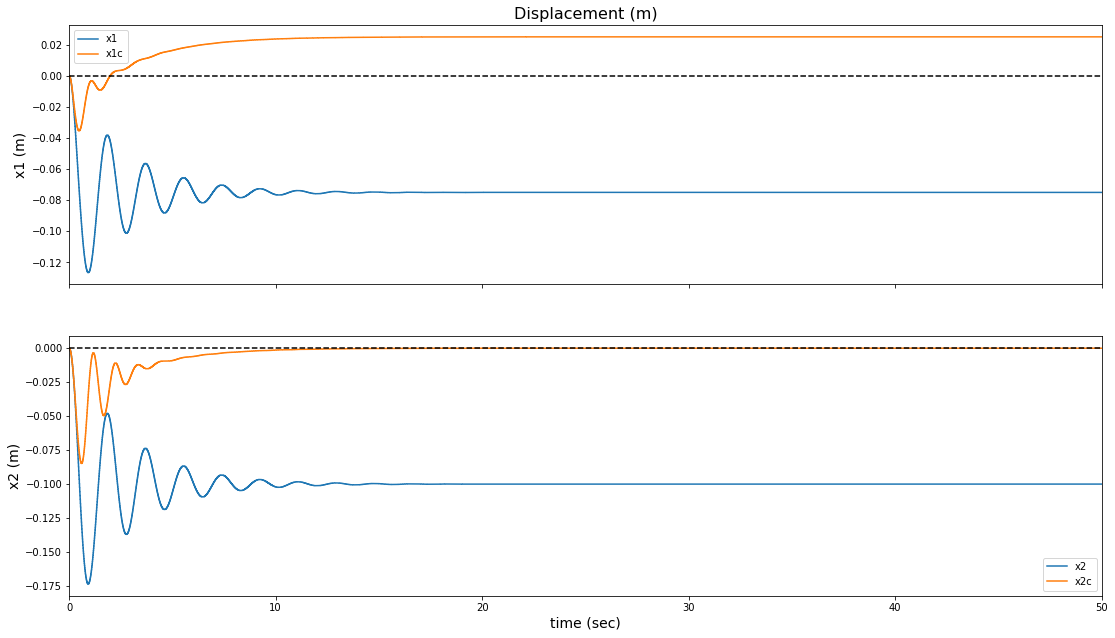

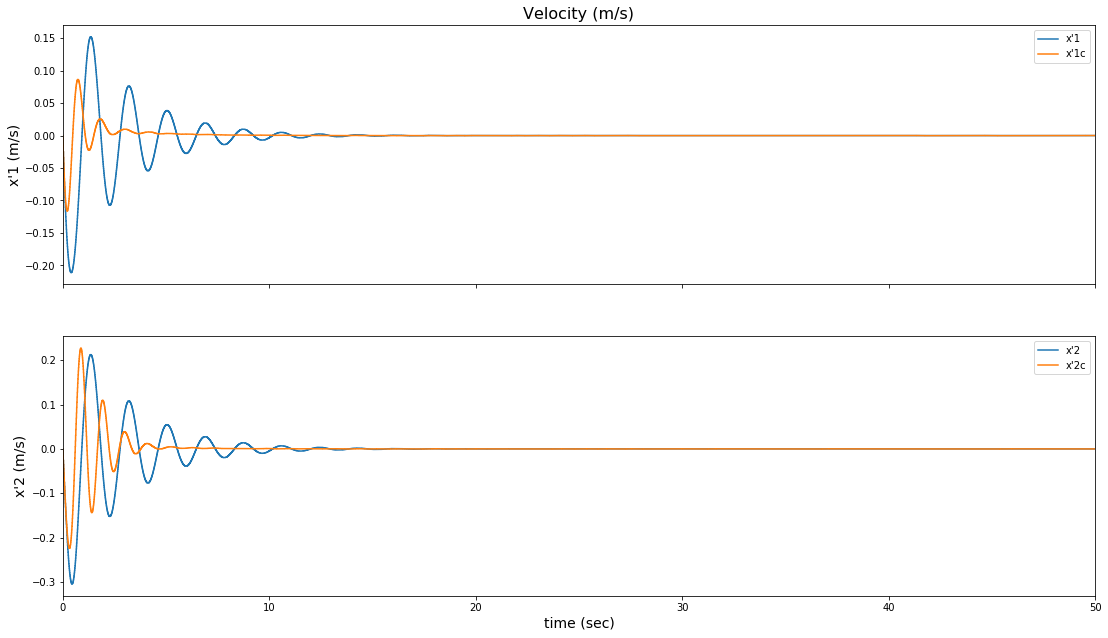

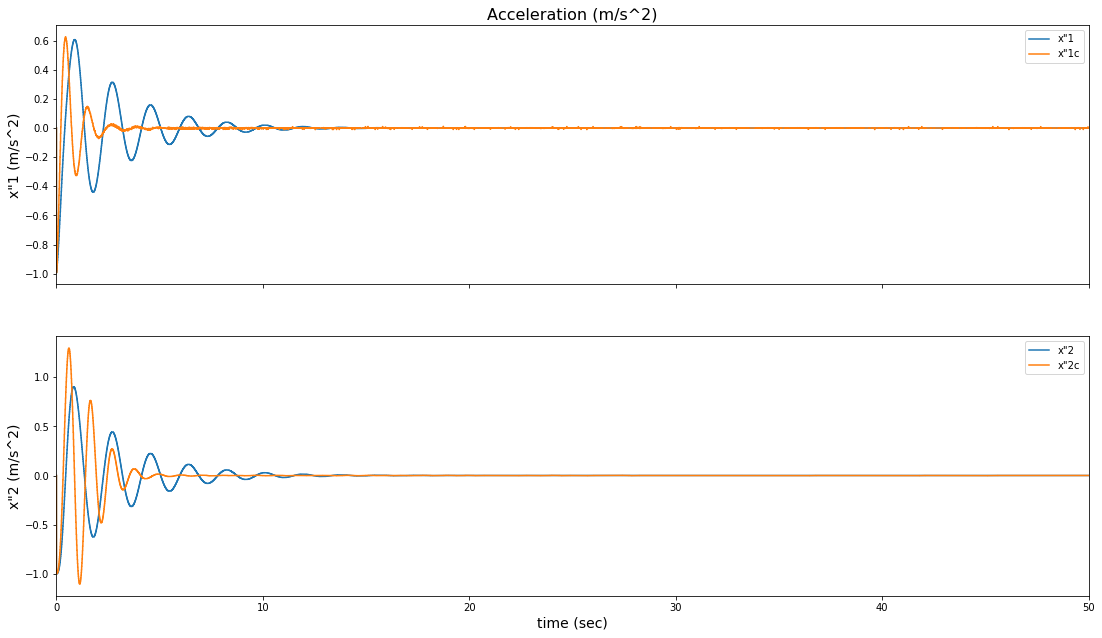

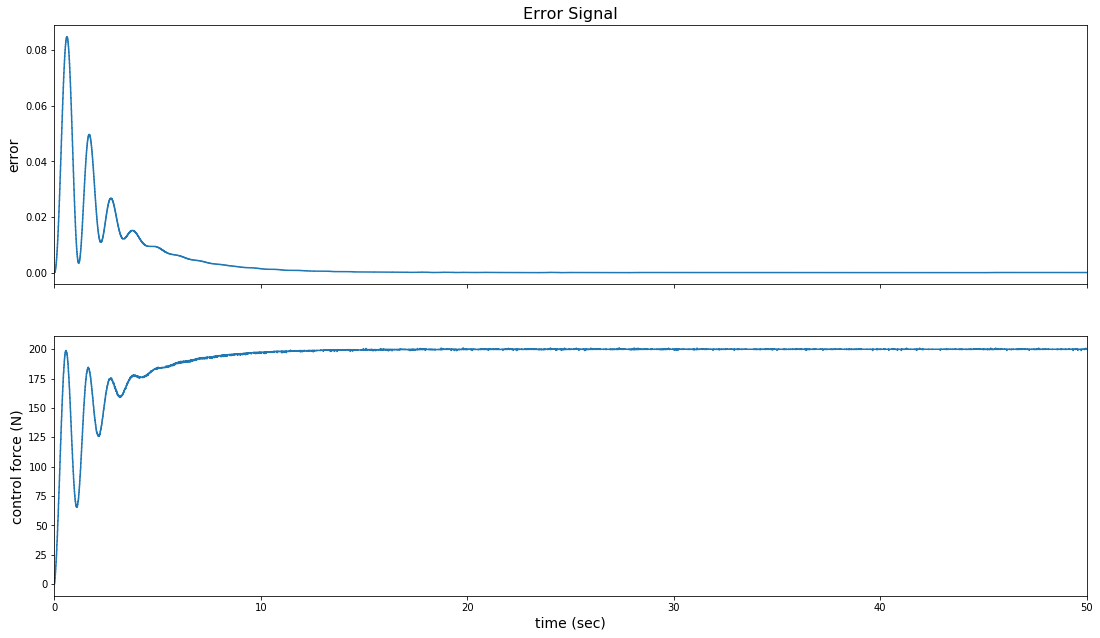

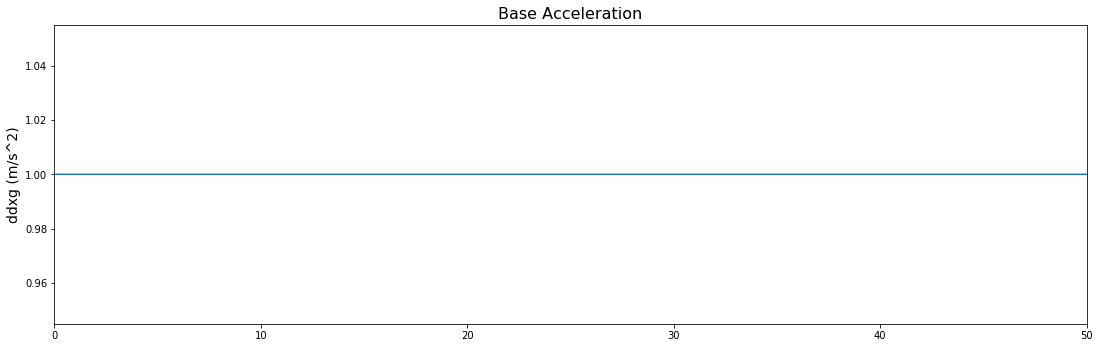

In [64]:
############SECURE CONTROLLED SYS
#########PID controller + Uncontrolled system     ########TEST########

from numpy import zeros,dot,atleast_1d
import numpy as np
from scipy import linalg
from matplotlib import pyplot as plt
from math import sqrt
import time
import numpy as np
import shamirproc
import shamirscheme as sss
from matplotlib import pyplot as plt
from scipy.interpolate import interp1d
from tabulate import tabulate
from decimal import Decimal
################################################################################


def dampparams(alpha,M,K): #return damping matrix 
    
    beta=0
    w1=sqrt(1-(sqrt(2)/2))*sqrt(K[1,1]/M[1,1]) #first natural freq
    w2=sqrt(1+(sqrt(2)/2))*sqrt(K[1,1]/M[1,1]) #second natural freq
    zeta1 = sqrt((2*sqrt(2)-2)/4)*alpha*sqrt(M[1,1]/K[1,1])+sqrt(2/(2-sqrt(2)))*beta*sqrt(M[1,1]/K[1,1])
    zeta2 = sqrt((2*sqrt(2)+2)/4)*alpha*sqrt(M[1,1]/K[1,1])+sqrt(2/(2+sqrt(2)))*beta*sqrt(M[1,1]/K[1,1])
    phiinv11 = (K[0,0]-w2**2*M[0,0])/(M[0,0]*(w1**2-w2**2))
    phiinv12 = K[0,1]/(M[0,0]*(w1**2-w2**2))
    phiinv21 = -(K[0,0]-w1**2*M[0,0])/(M[0,0]*(w1**2-w2**2))
    phiinv22 = -K[0,1]/(M[0,0]*(w1**2-w2**2))
    phiinv=np.array([[phiinv11,phiinv12],[phiinv21,phiinv22]])
    C1=2*zeta1*w1*(M[0,0]+(M[1,1]*(K[0,0]-w1**2*M[0,0])**2)/K[0,1]**2)
    C2=2*zeta2*w2*(M[0,0]+(M[1,1]*(K[0,0]-w2**2*M[0,0])**2)/K[0,1]**2)
    c = np.matmul(np.matmul(np.transpose(phiinv),np.array([[C1,0],[0,C2]])),phiinv)

    return c


def Newmark_coefficients(dt):
    alpha=0.25
    delta=0.5

    a0=1/(alpha*(dt**2))
    a1=delta/(alpha*dt)
    a2=1/(alpha*dt)
    a3=(1/(2*alpha))-1
    a4=(delta/alpha)-1
    a5=(dt/2)*((delta/alpha)-2)
    a6=dt*(1-delta)
    a7=delta*dt

    return a0,a1,a2,a3,a4,a5,a6,a7

################################################################################

def Newmark_initialize(ndof,a0,a1,M,C,K,NT,DI,VI):
    
    nlength=len(atleast_1d(M)) 

    KH=zeros((ndof,ndof),float)

    KH=K+a0*M+a1*C

    if(nlength==1):

        U=zeros(NT,float)
        Ud=zeros(NT,float)
        Udd=zeros(NT,float)

        U[0]=DI
        Ud[0]=VI
            
    else:

        U=zeros((ndof,NT),float)
        Ud=zeros((ndof,NT),float)
        Udd=zeros((ndof,NT),float)

        U[:,0]=DI
        Ud[:,0]=VI
    return U,Ud,Udd,KH

def Newmark_PID(F,server,t,scale,M,alpha,K,R,r,kp,ki,kd,VI,DI,dt,Tf,ndof,ddxg):
    """
    input

    M = mass matrix
    alpha = hyperparameter (for zeta configuration in order to obtain damping matrix)
    K = stiffness matrix
    


    VI = initial velocity
    DI = initial displacement

      dt = time step
      NT = number of time points
    ndof = number of degrees of freedom

    output

      U = displacement
     Ud = velocity
    Udd = acceleration

    """
#uncontrolled sys    
    a0,a1,a2,a3,a4,a5,a6,a7=Newmark_coefficients(dt)
    NT=floor(Tf/dt)
    C=dampparams(alpha,M,K)
    U,Ud,Udd,KH=Newmark_initialize(ndof,a0,a1,M,C,K,NT,DI,VI)
    taim=np.linspace(0,Tf,NT)
    f1=0
    f2=0
    
    for i in range (1,NT):
        R=np.array([f1-M[0,0]*ddxg,f2-M[1,1]*ddxg])
        V1=(a1*U[:,i-1]+a4*Ud[:,i-1]+a5*Udd[:,i-1])
        V2=(a0*U[:,i-1]+a2*Ud[:,i-1]+a3*Udd[:,i-1])
        CV=dot(C,V1)
        MA=dot(M,V2)
        FH=R+MA+CV

#  solve for displacements

        if(ndof>1):
            Un = linalg.solve(KH, FH)
        else:
            Un=FH/KH

        Uddn=a0*(Un-U[:,i-1])-a2*Ud[:,i-1]-a3*Udd[:,i-1]
        Udn=Ud[:,i-1]+a6*Udd[:,i-1]+a7*Uddn


        U[:,i]=Un
        Ud[:,i]=Udn
        Udd[:,i]=Uddn
        
#### control system
    es=sss.share(F,0,t,server,scale)
    f2cs=0
    f1cs=0
    integral_prevs=sss.share(F,0,t,server,scale)
    eprevs = sss.share(F,0,t,server,scale)
    errors=[]
    f1conts=[]
    errorsh = []
    errorsh.append(eprevs)
    errors.append(0)
    f1conts.append(0)
    DDxgs=[]
    DDxgs.append(ddxg)
    deltast1cs=[]
    deltast2cs=[]
    deltast1cs.append((f1cs+f2cs-3*M[1,1]*ddxg)/K[1,1])
    deltast2cs.append((f1cs+2*f2cs-4*M[1,1]*ddxg)/K[1,1])
    Ucs,Udcs,Uddcs,KHcs=Newmark_initialize(ndof,a0,a1,M,C,K,NT,DI,VI)
    rs = sss.share(F,r,t,server,scale)
    Ucs2 = sss.share(F,-Ucs[1,0],t,server,scale)
    rec=sss.basispoly(F,server)
    dts=sss.share(F,dt,t,server,scale)
    invdts=sss.share(F,1/(2*dt),t,server,scale)
    kp=sss.share(F,kp,t,server,scale)
    ki=sss.share(F,ki,t,server,scale)
    kd=sss.share(F,kd,t,server,scale)
    
    for i in range (1,NT):
        es = shamirproc.add(F,rs,Ucs2,t,server,scale) #sensor is located on the second mass
        integerals = shamirproc.add(F,integral_prevs, shamirproc.mult(F,es,dts,t,server,scale),t,server,scale)
        f11cs = shamirproc.mult(F,kp,es,t,server,scale) #proportional
        f12cs = shamirproc.mult(F,ki,integerals,t,server,scale) #Integral
        f13cs = shamirproc.mult(F,shamirproc.mult(F,kd,shamirproc.add(F,3*es,
                                                                      shamirproc.add(F,-4*eprevs,errorsh[i-2],t,server,scale),t,server,scale)
                                                  ,t,server,scale),invdts,t,server,scale) #derivative
        f1cs = shamirproc.add(F,f11cs,shamirproc.add(F,f12cs,f13cs,t,server,scale),t,server,scale) #control force
   #     shamirproc.mult(F,kp,es,t,server,scale)+shamirproc.mult(F,ki,integerals,t,server,scale) 
   #     +shamirproc.mult(F,shamirproc.mult(F,kd,shamirproc.add(F,es,eprevs,t,server,scale),t,server,scale),invdts,t,server,scale) 
        
        Rcs=np.array([sss.rec(F,f1cs,rec,scale)-M[0,0]*ddxg,f2cs-M[1,1]*ddxg])
        V1cs=(a1*Ucs[:,i-1]+a4*Udcs[:,i-1]+a5*Uddcs[:,i-1])
        V2cs=(a0*Ucs[:,i-1]+a2*Udcs[:,i-1]+a3*Uddcs[:,i-1])
        CVcs=dot(C,V1cs)
        MAcs=dot(M,V2cs)
        FHcs=Rcs+MAcs+CVcs

#  solve for displacements

        if(ndof>1):
            Uncs = linalg.solve(KHcs, FHcs)
        else:
            Uncs=FHcs/KHcs

        Uddncs=a0*(Uncs-Ucs[:,i-1])-a2*Udcs[:,i-1]-a3*Uddcs[:,i-1]
        Udncs=Udcs[:,i-1]+a6*Uddcs[:,i-1]+a7*Uddncs
        Ucs2=sss.share(F,-Uncs[1],t,server,scale)
        
        #eprevs = sss.share(F,-sss.rec(F,es,rec,scale),t,server,scale);
        eprevs=es
        integral_prevs = integerals
        Ucs[:,i]=Uncs
        Udcs[:,i]=Udncs
        Uddcs[:,i]=Uddncs
        errorsh.append(es)
        errors.append(sss.rec(F,es,rec,scale))
        f1conts.append(sss.rec(F,f1cs,rec,scale))
        deltast1cs.append((f1cs+f2cs-3*M[1,1]*ddxg)/K[1,1])
        deltast2cs.append((f1cs+2*f2cs-4*M[1,1]*ddxg)/K[1,1])
        DDxgs.append(ddxg)
        
        
#  delta static
    deltast1 = (f1+f2-3*M[1,1]*ddxg)/K[1,1]
    deltast2 = (f1+2*f2-4*M[1,1]*ddxg)/K[1,1]
    
    #Displacements
    fig,axs = plt.subplots(2, 1)
    fig.set_size_inches(18.5, 10.5, forward=True)
    axs[0].step(taim,U[0,:])
    axs[0].step(taim,Ucs[0,:])
    axs[0].axhline(y = r, color = 'black', linestyle = '--')
    axs[0].set_title('Displacement (m)',fontsize=16)
    axs[0].set_xlim(0,Tf)
    axs[0].legend(['x1','x1c'])
    axs[0].set_ylabel('x1 (m)',fontsize=14)
    axs[0].label_outer()
    axs[1].step(taim,U[1,:])
    axs[1].step(taim,Ucs[1,:])
    axs[1].axhline(y = r, color = 'black', linestyle = '--')
    axs[1].set_xlim(0,Tf)
    axs[1].set_xlabel('time (sec)',fontsize=14)
    axs[1].set_ylabel('x2 (m)',fontsize=14)
    axs[1].legend(['x2','x2c'])
    
    
    #Velocities
    fig1,axs1 = plt.subplots(2, 1)
    fig1.set_size_inches(18.5, 10.5, forward=True)
    axs1[0].step(taim,Ud[0,:])
    axs1[0].step(taim,Udcs[0,:])
    axs1[0].set_xlim(0,Tf)
    axs1[0].set_title('Velocity (m/s)',fontsize=16)
    axs1[0].set_ylabel("x'1 (m/s)",fontsize=14)
    axs1[0].legend(["x'1","x'1c"])
    axs1[0].label_outer()
    axs1[1].step(taim,Ud[1,:])
    axs1[1].step(taim,Udcs[1,:])
    axs1[1].set_xlim(0,Tf)
    axs1[1].set_ylabel("x'2 (m/s)",fontsize=14)
    axs1[1].set_xlabel('time (sec)',fontsize=14)
    axs1[1].legend(["x'2","x'2c"])
    
    #Accelerations
    fig2,axs2 = plt.subplots(2, 1)
    fig2.set_size_inches(18.5, 10.5, forward=True)
    axs2[0].step(taim,Udd[0,:])
    axs2[0].step(taim,Uddcs[0,:])
    axs2[0].set_xlim(0,Tf)
    axs2[0].set_title('Acceleration (m/s^2)',fontsize=16)
    axs2[0].set_ylabel('x"1 (m/s^2)',fontsize=14)
    axs2[0].legend(['x"1','x"1c'])
    axs2[0].label_outer()
    axs2[1].step(taim,Udd[1,:])
    axs2[1].step(taim,Uddcs[1,:])
    axs2[1].set_xlim(0,Tf)
    axs2[1].set_ylabel('x"2 (m/s^2)',fontsize=14)
    axs2[1].set_xlabel('time (sec)',fontsize=14)
    axs2[1].legend(['x"2','x"2c'])
    
    #Error and control force
    fig3,axs3 = plt.subplots(2, 1)
    fig3.set_size_inches(18.5, 10.5, forward=True)
    axs3[0].step(taim,errors)
    axs3[0].set_xlim(0,Tf)
    axs3[0].set_title('Error Signal',fontsize=16)
    axs3[0].set_ylabel('error',fontsize=14)
    axs3[0].label_outer()
    axs3[1].step(taim,f1conts)
    axs3[1].set_xlim(0,Tf)
    axs3[1].set_ylabel('control force (N)',fontsize=14)
    axs3[1].set_xlabel('time (sec)',fontsize=14)
    
    #dsturbances
    fig4,axs4 = plt.subplots(1, 1)
    fig4.set_size_inches(18.5, 5.5, forward=True)
    axs4.step(taim,DDxgs)
    axs4.set_xlim(0,Tf)
    axs4.set_title('Base Acceleration',fontsize=16)
    axs4.set_ylabel('ddxg (m/s^2)',fontsize=14)
    axs4.label_outer()
    return f1conts,errors#U,Ucs,Ud,Udd,NT,t,C
f1=0
f2=0
ddxg=1
M=np.array([[100,0],[0,50]])
K=np.array([[4000,-2000],[-2000,2000]])
R=np.array([f1-M[0,0]*ddxg,f2-M[1,1]*ddxg])
kp = 1.9e+03#100
ki = 1.39e+03#200
kd = 178 #200 
r=0 #refference input
F=GF(next_prime(2^60))
server=4
t=1 #shamir threshold 
scale=8
dt=0.01
ndof=2
Tf=50
alpha=1.5
resp=Newmark_PID(F,server,t,scale,M,alpha,K,R,r,kp,ki,kd,0,0,dt,Tf,ndof,ddxg)




In [66]:
resp[1]

[0,
 0.0,
 2.499e-05,
 0.00012497,
 0.00032487,
 0.00062454,
 0.00102373,
 0.00152206,
 0.00211901,
 0.00281387,
 0.00360578,
 0.00449366,
 0.00547624,
 0.00655204,
 0.00771934,
 0.00897616,
 0.01032028,
 0.01174925,
 0.0132603,
 0.01485041,
 0.0165163,
 0.01825442,
 0.02006094,
 0.02193178,
 0.02386256,
 0.02584869,
 0.0278853,
 0.02996731,
 0.03208939,
 0.03424604,
 0.03643151,
 0.03863987,
 0.04086505,
 0.04310082,
 0.04534083,
 0.04757862,
 0.04980767,
 0.05202136,
 0.05421308,
 0.05637618,
 0.05850406,
 0.0605901,
 0.06262781,
 0.06461074,
 0.06653261,
 0.06838722,
 0.07016861,
 0.07187092,
 0.07348858,
 0.07501621,
 0.07644877,
 0.0777814,
 0.0790096,
 0.08012916,
 0.08113623,
 0.08202729,
 0.08279921,
 0.08344926,
 0.08397508,
 0.08437477,
 0.08464681,
 0.08479013,
 0.08480412,
 0.08468857,
 0.08444373,
 0.08407026,
 0.08356929,
 0.08294236,
 0.08219148,
 0.08131903,
 0.08032784,
 0.07922115,
 0.07800259,
 0.07667617,
 0.07524628,
 0.07371764,
 0.07209532,
 0.07038469,
 0.068591

/opt/sagemath-9.1/local/lib/python3.7/site-packages/scipy/linalg/__init__.py:212: DeprecationWarning: The module numpy.dual is deprecated.  Instead of using dual, use the functions directly from numpy or scipy.
  from numpy.dual import register_func
/opt/sagemath-9.1/local/lib/python3.7/site-packages/scipy/special/orthogonal.py:81: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  from numpy import (exp, inf, pi, sqrt, floor, sin, cos, around, int,
/opt/sagemath-9.1/local/lib/python3.7/site-packages/scipy/sparse/sputils.py:23: DeprecationWarning: `np

running time of insecure controller: 1.8367047309875488 s
running time of secure controller: 13.837474346160889 s
running time of secure /running time of insecure : 7.53385893372248
+------------+------------------------------+-----------------------------+
|            | Integral Absolute Error(IAE) | Integral Squared Error(ISE) |
+------------+------------------------------+-----------------------------+
|   b-w x1   |          1.830E-06           |          5.202E-12          |
|   b-w x2   |          3.512E-06           |          1.973E-11          |
|  b-w x'1   |          1.142E-05           |          2.055E-10          |
|  b-w x'2   |          2.149E-05           |          6.972E-10          |
|  b-w x"1   |          2.392E-04           |          1.074E-07          |
|  b-w x"2   |          1.404E-04           |          2.943E-08          |
| b-w errors |          3.511E-06           |          1.973E-11          |
| b-w forces |          2.409E-02           |          1.0

array([[ 252.26892458, -126.13446229],
       [-126.13446229,  126.13446229]])

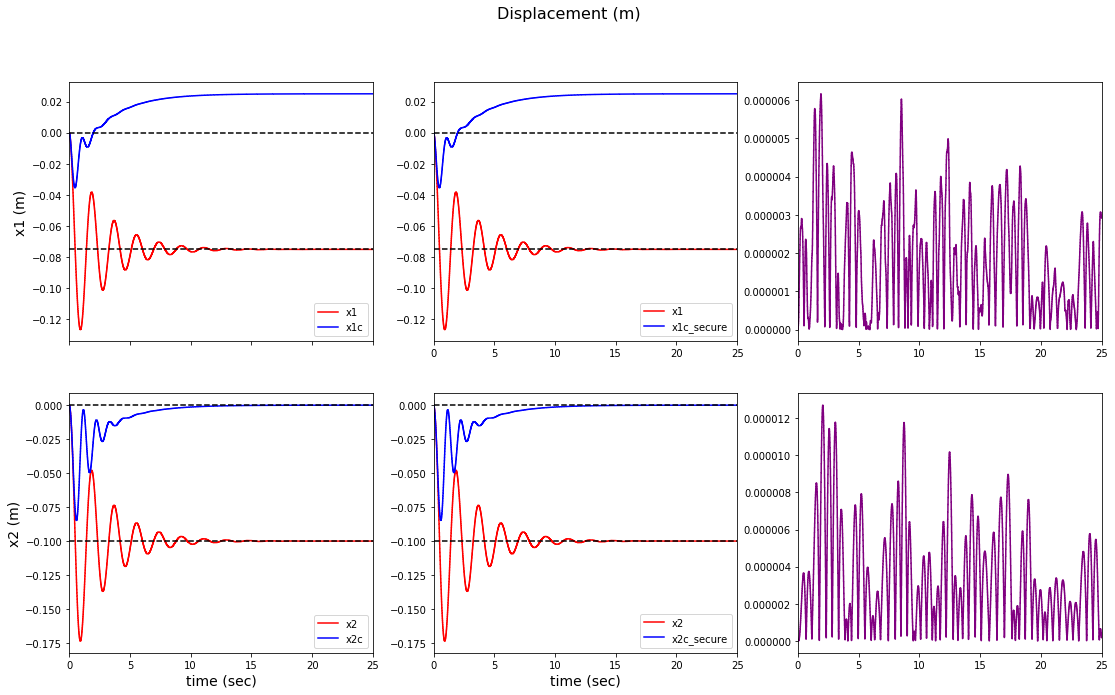

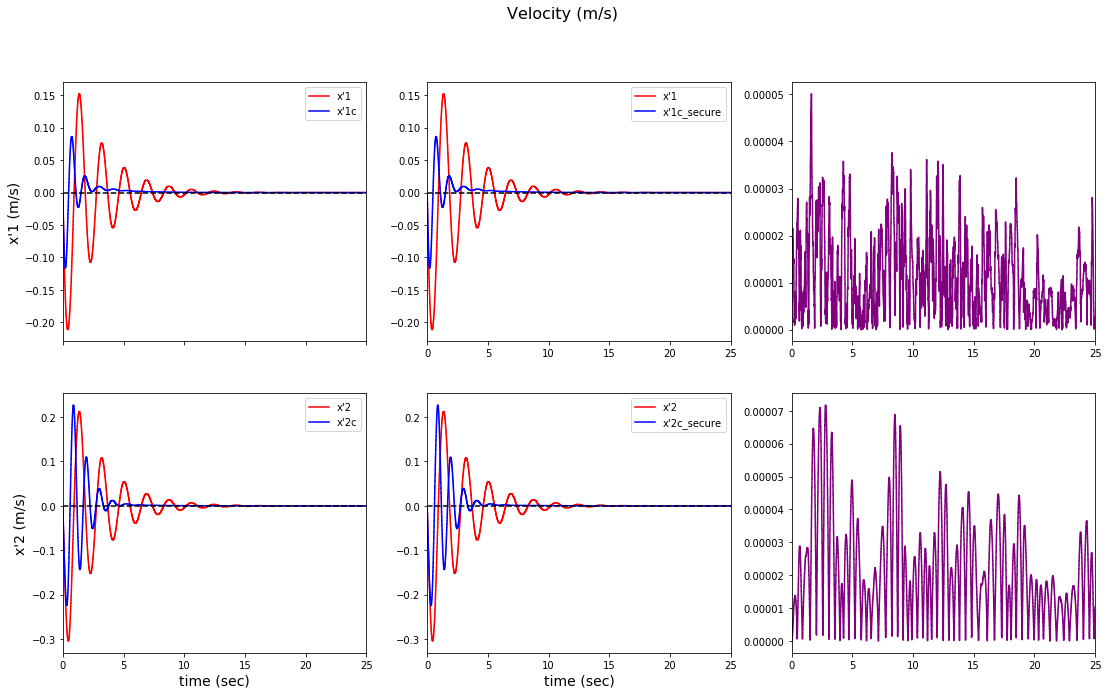

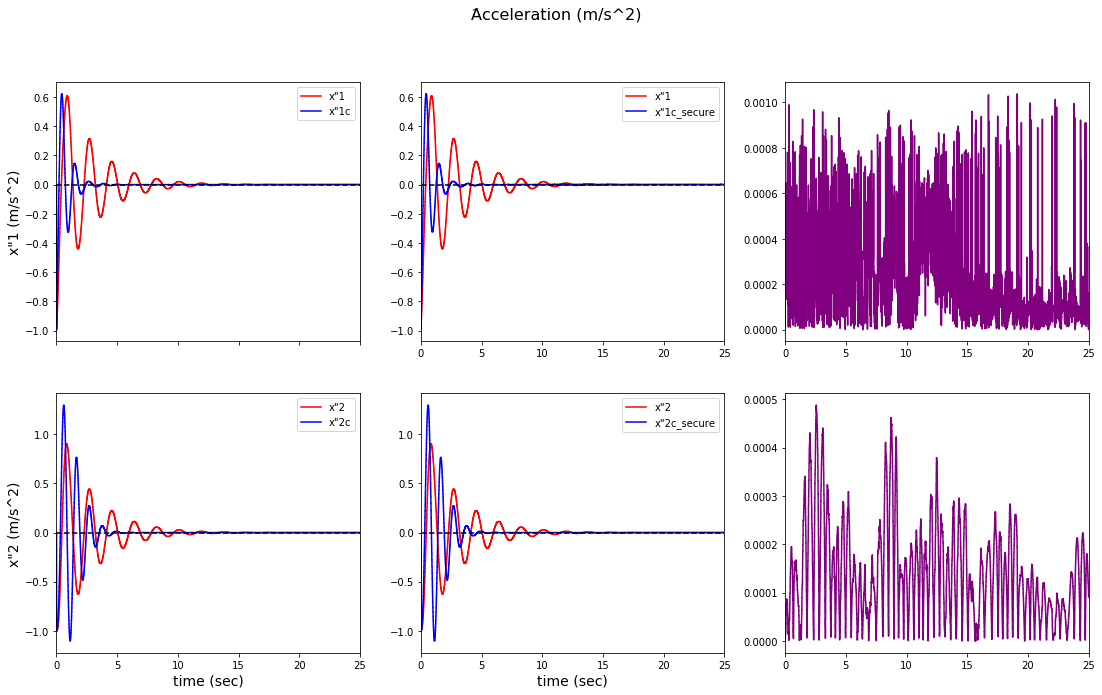

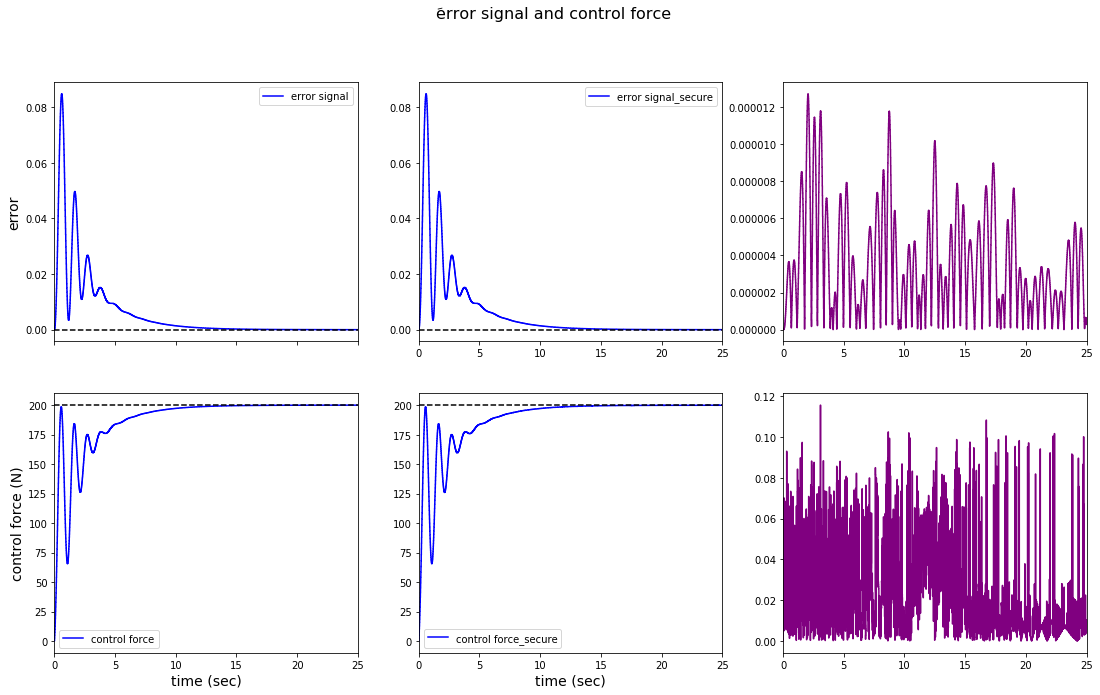

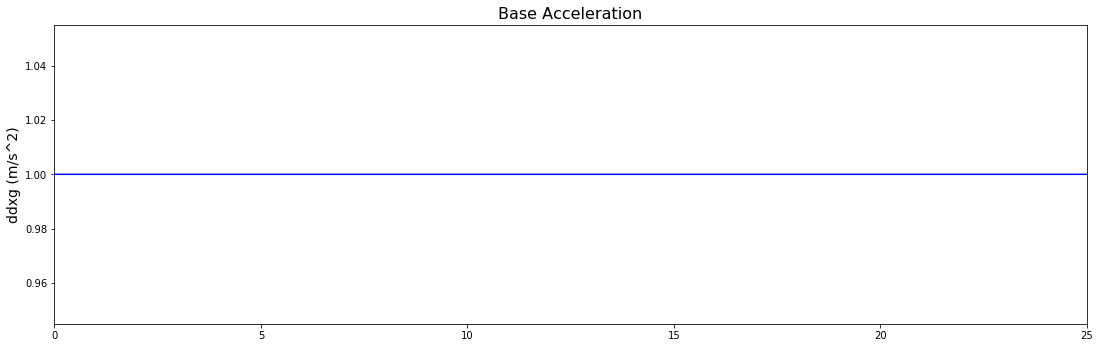

In [7]:
############SECURE CONTROLLED SYS #########################entire system##########################################
#########PID controller + Uncontrolled system     ########TEST########

from numpy import zeros,dot,atleast_1d
import numpy as np
from scipy import linalg
from matplotlib import pyplot as plt
from math import sqrt
import time
import numpy as np
import shamirproc
import shamirscheme as sss
from matplotlib import pyplot as plt
from scipy.interpolate import interp1d
from tabulate import tabulate
from decimal import Decimal
################################################################################


def dampparams(alpha,M,K): #return damping matrix 
    
    beta=0
    w1=sqrt(1-(sqrt(2)/2))*sqrt(K[1,1]/M[1,1]) #first natural freq
    w2=sqrt(1+(sqrt(2)/2))*sqrt(K[1,1]/M[1,1]) #second natural freq
    zeta1 = sqrt((2*sqrt(2)-2)/4)*alpha*sqrt(M[1,1]/K[1,1])+sqrt(2/(2-sqrt(2)))*beta*sqrt(M[1,1]/K[1,1])
    zeta2 = sqrt((2*sqrt(2)+2)/4)*alpha*sqrt(M[1,1]/K[1,1])+sqrt(2/(2+sqrt(2)))*beta*sqrt(M[1,1]/K[1,1])
    phiinv11 = (K[0,0]-w2**2*M[0,0])/(M[0,0]*(w1**2-w2**2))
    phiinv12 = K[0,1]/(M[0,0]*(w1**2-w2**2))
    phiinv21 = -(K[0,0]-w1**2*M[0,0])/(M[0,0]*(w1**2-w2**2))
    phiinv22 = -K[0,1]/(M[0,0]*(w1**2-w2**2))
    phiinv=np.array([[phiinv11,phiinv12],[phiinv21,phiinv22]])
    C1=2*zeta1*w1*(M[0,0]+(M[1,1]*(K[0,0]-w1**2*M[0,0])**2)/K[0,1]**2)
    C2=2*zeta2*w2*(M[0,0]+(M[1,1]*(K[0,0]-w2**2*M[0,0])**2)/K[0,1]**2)
    c = np.matmul(np.matmul(np.transpose(phiinv),np.array([[C1,0],[0,C2]])),phiinv)

    return c


def Newmark_coefficients(dt):
    alpha=0.25
    delta=0.5

    a0=1/(alpha*(dt**2))
    a1=delta/(alpha*dt)
    a2=1/(alpha*dt)
    a3=(1/(2*alpha))-1
    a4=(delta/alpha)-1
    a5=(dt/2)*((delta/alpha)-2)
    a6=dt*(1-delta)
    a7=delta*dt

    return a0,a1,a2,a3,a4,a5,a6,a7

################################################################################

def Newmark_initialize(ndof,a0,a1,M,C,K,NT,DI,VI):
    
    nlength=len(atleast_1d(M)) 

    KH=zeros((ndof,ndof),float)

    KH=K+a0*M+a1*C

    if(nlength==1):

        U=zeros(NT,float)
        Ud=zeros(NT,float)
        Udd=zeros(NT,float)

        U[0]=DI
        Ud[0]=VI
            
    else:

        U=zeros((ndof,NT),float)
        Ud=zeros((ndof,NT),float)
        Udd=zeros((ndof,NT),float)

        U[:,0]=DI
        Ud[:,0]=VI
    return U,Ud,Udd,KH

def Newmark_PID(F,server,t,scale,M,alpha,K,R,r,kp,ki,kd,VI,DI,dt,Tf,ndof,ddxg):
    """
    input

    M = mass matrix
    alpha = hyperparameter (for zeta configuration in order to obtain damping matrix)
    K = stiffness matrix
    


    VI = initial velocity
    DI = initial displacement

      dt = time step
      NT = number of time points
    ndof = number of degrees of freedom

    output

      U = displacement
     Ud = velocity
    Udd = acceleration

    """
#uncontrolled sys    
    a0,a1,a2,a3,a4,a5,a6,a7=Newmark_coefficients(dt)
    NT=floor(Tf/dt)
    C=dampparams(alpha,M,K)
    U,Ud,Udd,KH=Newmark_initialize(ndof,a0,a1,M,C,K,NT,DI,VI)
    taim=np.linspace(0,Tf,NT)
    f1=0
    f2=0
    
    for i in range (1,NT):
        R=np.array([f1-M[0,0]*ddxg,f2-M[1,1]*ddxg])
        V1=(a1*U[:,i-1]+a4*Ud[:,i-1]+a5*Udd[:,i-1])
        V2=(a0*U[:,i-1]+a2*Ud[:,i-1]+a3*Udd[:,i-1])
        CV=dot(C,V1)
        MA=dot(M,V2)
        FH=R+MA+CV

#  solve for displacements

        if(ndof>1):
            Un = linalg.solve(KH, FH)
        else:
            Un=FH/KH

        Uddn=a0*(Un-U[:,i-1])-a2*Ud[:,i-1]-a3*Udd[:,i-1]
        Udn=Ud[:,i-1]+a6*Udd[:,i-1]+a7*Uddn


        U[:,i]=Un
        Ud[:,i]=Udn
        Udd[:,i]=Uddn
        
        
#### insecure control system
    e=0
    f2c=0
    f1c=0
    integral_prev=0
    eprev = 0
    error=[]
    f1cont=[]
    error.append(0)
    f1cont.append(0)
    DDxg=[]
    DDxg.append(ddxg)
    deltast1c=[]
    deltast2c=[]
    deltast1c.append((f1c+f2c-3*M[1,1]*ddxg)/K[1,1])
    deltast2c.append((f1c+2*f2c-4*M[1,1]*ddxg)/K[1,1]);
    Uc,Udc,Uddc,KHc=Newmark_initialize(ndof,a0,a1,M,C,K,NT,DI,VI)
    tic=time.time()
    for i in range (1,NT):
        e = r-Uc[1,i-1]; #sensor is located on second mass
        integeral = integral_prev + e*dt
        f1c = kp*e + ki*integeral + kd*(error[i-2]-4*eprev+3*e)/(2*dt)
        Rc=np.array([f1c-M[0,0]*ddxg,f2c-M[1,1]*ddxg])
        V1c=(a1*Uc[:,i-1]+a4*Udc[:,i-1]+a5*Uddc[:,i-1])
        V2c=(a0*Uc[:,i-1]+a2*Udc[:,i-1]+a3*Uddc[:,i-1])
        CVc=dot(C,V1c)
        MAc=dot(M,V2c)
        FHc=Rc+MAc+CVc

#  solve for displacements

        if(ndof>1):
            Unc = linalg.solve(KHc, FHc)
        else:
            Unc=FHc/KHc

        Uddnc=a0*(Unc-Uc[:,i-1])-a2*Udc[:,i-1]-a3*Uddc[:,i-1]
        Udnc=Udc[:,i-1]+a6*Uddc[:,i-1]+a7*Uddnc

        eprev = e;
        integral_prev = integeral
        Uc[:,i]=Unc
        Udc[:,i]=Udnc
        Uddc[:,i]=Uddnc
        error.append(e)
        f1cont.append(f1c)
        deltast1c.append((f1c+f2c-3*M[1,1]*ddxg)/K[1,1])
        deltast2c.append((f1c+2*f2c-4*M[1,1]*ddxg)/K[1,1])
        DDxg.append(ddxg)
    toc=time.time()    
#### secure control system
    es=sss.share(F,0,t,server,scale)
    f2cs=0
    f1cs=0
    integral_prevs=sss.share(F,0,t,server,scale)
    eprevs = sss.share(F,0,t,server,scale)
    errors=[]
    f1conts=[]
    errorsh = []
    errorsh.append(eprevs)
    errors.append(0)
    f1conts.append(0)
    DDxgs=[]
    DDxgs.append(ddxg)
    deltast1cs=[]
    deltast2cs=[]
    deltast1cs.append((f1cs+f2cs-3*M[1,1]*ddxg)/K[1,1])
    deltast2cs.append((f1cs+2*f2cs-4*M[1,1]*ddxg)/K[1,1])
    Ucs,Udcs,Uddcs,KHcs=Newmark_initialize(ndof,a0,a1,M,C,K,NT,DI,VI)
    rs = sss.share(F,r,t,server,scale)
    Ucs2 = sss.share(F,-Ucs[1,0],t,server,scale)
    rec=sss.basispoly(F,server)
    dts=sss.share(F,dt,t,server,scale)
    invdts=sss.share(F,1/(2*dt),t,server,scale)
    kp=sss.share(F,kp,t,server,scale)
    ki=sss.share(F,ki,t,server,scale)
    kd=sss.share(F,kd,t,server,scale)
    tics=time.time()
    for i in range (1,NT):
        es = shamirproc.add(F,rs,Ucs2,t,server,scale) #sensor is located on the second mass
        integerals = shamirproc.add(F,integral_prevs, shamirproc.mult(F,es,dts,t,server,scale),t,server,scale)
        f11cs = shamirproc.mult(F,kp,es,t,server,scale) #proportional
        f12cs = shamirproc.mult(F,ki,integerals,t,server,scale) #Integral
        f13cs = shamirproc.mult(F,shamirproc.mult(F,kd,shamirproc.add(F,3*es,
                                                                      shamirproc.add(F,-4*eprevs,errorsh[i-2],t,server,scale),t,server,scale)
                                                  ,t,server,scale),invdts,t,server,scale) #derivative
        f1cs = shamirproc.add(F,f11cs,shamirproc.add(F,f12cs,f13cs,t,server,scale),t,server,scale) #control force
   #     shamirproc.mult(F,kp,es,t,server,scale)+shamirproc.mult(F,ki,integerals,t,server,scale) 
   #     +shamirproc.mult(F,shamirproc.mult(F,kd,shamirproc.add(F,es,eprevs,t,server,scale),t,server,scale),invdts,t,server,scale) 
        
        Rcs=np.array([sss.rec(F,f1cs,rec,scale)-M[0,0]*ddxg,f2cs-M[1,1]*ddxg])
        V1cs=(a1*Ucs[:,i-1]+a4*Udcs[:,i-1]+a5*Uddcs[:,i-1])
        V2cs=(a0*Ucs[:,i-1]+a2*Udcs[:,i-1]+a3*Uddcs[:,i-1])
        CVcs=dot(C,V1cs)
        MAcs=dot(M,V2cs)
        FHcs=Rcs+MAcs+CVcs
    
#  solve for displacements

        if(ndof>1):
            Uncs = linalg.solve(KHcs, FHcs)
        else:
            Uncs=FHcs/KHcs

        Uddncs=a0*(Uncs-Ucs[:,i-1])-a2*Udcs[:,i-1]-a3*Uddcs[:,i-1]
        Udncs=Udcs[:,i-1]+a6*Uddcs[:,i-1]+a7*Uddncs
        Ucs2=sss.share(F,-Uncs[1],t,server,scale)
        
        eprevs=es
        integral_prevs = integerals
        Ucs[:,i]=Uncs
        Udcs[:,i]=Udncs
        Uddcs[:,i]=Uddncs
        errorsh.append(es)
        errors.append(sss.rec(F,es,rec,scale))
        f1conts.append(sss.rec(F,f1cs,rec,scale))
        deltast1cs.append((f1cs+f2cs-3*M[1,1]*ddxg)/K[1,1])
        deltast2cs.append((f1cs+2*f2cs-4*M[1,1]*ddxg)/K[1,1])
        DDxgs.append(ddxg)
    tocs=time.time()
    print('running time of insecure controller: {0} s'.format(toc-tic))
    print('running time of secure controller: {0} s'.format(tocs-tics))
    print('running time of secure /running time of insecure : {0}'.format((tocs-tics)/(toc-tic)))
##differences
    x1diffrence = abs(np.array(Uc[0,:])-np.array(Ucs[0,:]))
    dx1diffrence = abs(np.array(Udc[0,:])-np.array(Udcs[0,:]))
    ddx1diffrence = abs(np.array(Uddc[0,:])-np.array(Uddcs[0,:]))
    x2diffrence = abs(np.array(Uc[1,:])-np.array(Ucs[1,:]))
    dx2diffrence = abs(np.array(Udc[1,:])-np.array(Udcs[1,:]))
    ddx2diffrence = abs(np.array(Uddc[1,:])-np.array(Uddcs[1,:]))
    errordiffrence = abs(np.array(error)-np.array(errors))
    forcediffrence = abs(np.array(f1cont)-np.array(f1conts))
    
    #table of defferences
    sx1=0
    for i in x1diffrence:
        sx1+=i**2
    IAEx1= '%.3E' % Decimal(str(sum(x1diffrence)/NT))
    ISEx1= '%.3E' % Decimal(str(sx1/NT))

    sx2=0
    for i in x2diffrence:
        sx2+=i**2
    IAEx2= '%.3E' % Decimal(str(sum(x2diffrence)/NT))
    ISEx2= '%.3E' % Decimal(str(sx2/NT))
    
    sdx1=0
    for i in dx1diffrence:
        sdx1+=i**2
    IAEdx1= '%.3E' % Decimal(str(sum(dx1diffrence)/NT))
    ISEdx1= '%.3E' % Decimal(str(sdx1/NT))

    sdx2=0
    for i in dx2diffrence:
        sdx2+=i**2
    IAEdx2= '%.3E' % Decimal(str(sum(dx2diffrence)/NT))
    ISEdx2= '%.3E' % Decimal(str(sdx2/NT))
    
    sddx1=0
    for i in ddx1diffrence:
        sddx1+=i**2
    IAEddx1= '%.3E' % Decimal(str(sum(ddx1diffrence)/NT))
    ISEddx1= '%.3E' % Decimal(str(sddx1/NT))

    sddx2=0
    for i in ddx2diffrence:
        sddx2+=i**2
    IAEddx2= '%.3E' % Decimal(str(sum(ddx2diffrence)/NT))
    ISEddx2= '%.3E' % Decimal(str(sddx2/NT))
    
    se=0
    for i in errordiffrence:
        se+=i**2
    IAEse= '%.3E' % Decimal(str(sum(errordiffrence)/NT))
    ISEse= '%.3E' % Decimal(str(se/NT))
    
    sf=0
    for i in forcediffrence:
        sf+=i**2
    IAEsf= '%.3E' % Decimal(str(sum(forcediffrence)/NT))
    ISEsf= '%.3E' % Decimal(str(sf/NT))
    
    table = [["b-w x1",IAEx1,ISEx1]
             ,["b-w x2",IAEx2,ISEx2]
             ,["b-w x'1",IAEdx1,ISEdx1]
            ,["b-w x'2",IAEdx2,ISEdx2]
            ,['b-w x"1',IAEddx1,ISEddx1]
            ,['b-w x"2',IAEddx2,ISEddx2]
            ,["b-w errors",IAEse,ISEse]
            ,["b-w forces",IAEsf,ISEsf]]

    headers = ['',"Integral Absolute Error(IAE)", "Integral Squared Error(ISE)"]

    print(tabulate(table, headers, tablefmt="pretty",disable_numparse=True))
    
#  delta static
    deltast1 = (f1+f2-3*M[1,1]*ddxg)/K[1,1]
    deltast2 = (f1+2*f2-4*M[1,1]*ddxg)/K[1,1]
    
    #Displacements
    fig,axs = plt.subplots(2,3)
    fig.set_size_inches(18.5, 10.5, forward=True)
    fig.suptitle('Displacement (m)', fontsize=16)
    
    axs[0,0].step(taim,U[0,:], color='red')
    axs[0,0].step(taim,Uc[0,:], color='blue')
    axs[0,0].axhline(y = r, color = 'black', linestyle = '--')
    axs[0,0].axhline(y = deltast1, color = 'black', linestyle = '--')
    axs[0,0].set_xlim(0,Tf)
    axs[0,0].legend(['x1','x1c'])
    axs[0,0].set_xlabel('time (sec)',fontsize=14)
    axs[0,0].set_ylabel('x1 (m)',fontsize=14)
    axs[0,0].label_outer()
    
    axs[0,1].step(taim,U[0,:], color='red')
    axs[0,1].step(taim,Ucs[0,:], color='blue')
    axs[0,1].axhline(y = r, color = 'black', linestyle = '--')
    axs[0,1].axhline(y = deltast1, color = 'black', linestyle = '--')
    axs[0,1].set_xlim(0,Tf)
    axs[0,1].legend(['x1','x1c_secure'])

    
    axs[0,2].step(taim,x1diffrence, color='purple')
    axs[0,2].set_xlim(0,Tf)
    
    axs[1,0].step(taim,U[1,:], color='red')
    axs[1,0].step(taim,Uc[1,:], color='blue')
    axs[1,0].axhline(y = r, color = 'black', linestyle = '--')
    axs[1,0].axhline(y = deltast2, color = 'black', linestyle = '--')
    axs[1,0].set_xlim(0,Tf)
    axs[1,0].set_xlabel('time (sec)',fontsize=14)
    axs[1,0].set_ylabel('x2 (m)',fontsize=14)
    axs[1,0].legend(['x2','x2c'])
    
    axs[1,1].step(taim,U[1,:], color='red')
    axs[1,1].step(taim,Ucs[1,:], color='blue')
    axs[1,1].axhline(y = r, color = 'black', linestyle = '--')
    axs[1,1].axhline(y = deltast2, color = 'black', linestyle = '--')
    axs[1,1].set_xlim(0,Tf)
    axs[1,1].set_xlabel('time (sec)',fontsize=14)
    axs[1,1].legend(['x2','x2c_secure'])

    axs[1,2].step(taim,x2diffrence, color='purple')
    axs[1,2].set_xlim(0,Tf)

    #Velocities
    fig1,axs1 = plt.subplots(2, 3)
    fig1.set_size_inches(18.5, 10.5, forward=True)
    fig1.suptitle('Velocity (m/s)', fontsize=16)
    
    axs1[0,0].step(taim,Ud[0,:], color='red')
    axs1[0,0].step(taim,Udc[0,:], color='blue')
    axs1[0,0].set_xlim(0,Tf)
    axs1[0,0].legend(["x'1","x'1c"])
    axs1[0,0].set_xlabel('time (sec)',fontsize=14)
    axs1[0,0].set_ylabel("x'1 (m/s)",fontsize=14)
    axs1[0,0].axhline(y = 0, color = 'black', linestyle = '--')
    axs1[0,0].label_outer()
    
    axs1[0,1].step(taim,Ud[0,:], color='red')
    axs1[0,1].step(taim,Udcs[0,:], color='blue')
    axs1[0,1].set_xlim(0,Tf)
    axs1[0,1].legend(["x'1","x'1c_secure"])
    axs1[0,1].axhline(y = 0, color = 'black', linestyle = '--')

    
    axs1[0,2].step(taim,dx1diffrence, color='purple')
    axs1[0,2].set_xlim(0,Tf)
    
    axs1[1,0].step(taim,Ud[1,:], color='red')
    axs1[1,0].step(taim,Udc[1,:], color='blue')
    axs1[1,0].set_xlim(0,Tf)
    axs1[1,0].set_xlabel('time (sec)',fontsize=14)
    axs1[1,0].set_ylabel("x'2 (m/s)",fontsize=14)
    axs1[1,0].axhline(y = 0, color = 'black', linestyle = '--')
    axs1[1,0].legend(["x'2","x'2c"])

    axs1[1,1].step(taim,Ud[1,:], color='red')
    axs1[1,1].step(taim,Udcs[1,:], color='blue')
    axs1[1,1].set_xlim(0,Tf)
    axs1[1,1].legend(["x'2","x'2c_secure"])
    axs1[1,1].axhline(y = 0, color = 'black', linestyle = '--')
    axs1[1,1].set_xlabel('time (sec)',fontsize=14)
    
    axs1[1,2].step(taim,dx2diffrence, color='purple')
    axs1[1,2].set_xlim(0,Tf)
    
    
    #Accelerations
    fig2,axs2 = plt.subplots(2, 3)
    fig2.set_size_inches(18.5, 10.5, forward=True)    
    fig2.suptitle('َAcceleration (m/s^2)', fontsize=16)
    
    axs2[0,0].step(taim,Udd[0,:], color='red')
    axs2[0,0].step(taim,Uddc[0,:], color='blue')
    axs2[0,0].axhline(y = 0, color = 'black', linestyle = '--')
    axs2[0,0].set_xlim(0,Tf)
    axs2[0,0].legend(['x"1','x"1c'])
    axs2[0,0].set_xlabel('time (sec)',fontsize=14)
    axs2[0,0].set_ylabel('x"1 (m/s^2)',fontsize=14)
    axs2[0,0].label_outer()
    
    axs2[0,1].step(taim,Udd[0,:], color='red')
    axs2[0,1].step(taim,Uddcs[0,:], color='blue')
    axs2[0,1].axhline(y = 0, color = 'black', linestyle = '--')
    axs2[0,1].set_xlim(0,Tf)
    axs2[0,1].legend(['x"1','x"1c_secure'])
    
    axs2[0,2].step(taim,ddx1diffrence, color='purple')
    axs2[0,2].set_xlim(0,Tf)
    
    axs2[1,0].step(taim,Udd[1,:], color='red')
    axs2[1,0].step(taim,Uddc[1,:], color='blue')
    axs2[1,0].axhline(y = 0, color = 'black', linestyle = '--')
    axs2[1,0].set_xlim(0,Tf)
    axs2[1,0].set_xlabel('time (sec)',fontsize=14)
    axs2[1,0].set_ylabel('x"2 (m/s^2)',fontsize=14)
    axs2[1,0].legend(['x"2','x"2c'])
    
    axs2[1,1].step(taim,Udd[1,:], color='red')
    axs2[1,1].step(taim,Uddcs[1,:], color='blue')
    axs2[1,1].axhline(y = 0, color = 'black', linestyle = '--')
    axs2[1,1].set_xlim(0,Tf)
    axs2[1,1].set_xlabel('time (sec)',fontsize=14)
    axs2[1,1].legend(['x"2','x"2c_secure'])    
    
    axs2[1,2].step(taim,ddx2diffrence, color='purple')
    axs2[1,2].set_xlim(0,Tf)

    #Error and control force
    fig3,axs3 = plt.subplots(2, 3)
    fig3.set_size_inches(18.5, 10.5, forward=True)
    fig3.suptitle('َerror signal and control force', fontsize=16)
    axs3[0,0].step(taim,error, color='blue')
    axs3[0,0].set_xlim(0,Tf)
    axs3[0,0].set_ylabel('error',fontsize=14)
    axs3[0,0].legend(['error signal'])  
    axs3[0,0].axhline(y = 0, color = 'black', linestyle = '--')
    axs3[0,0].label_outer()
    
    axs3[0,1].step(taim,errors, color='blue')
    axs3[0,1].set_xlim(0,Tf)
    axs3[0,1].legend(['error signal_secure'])
    axs3[0,1].axhline(y = 0, color = 'black', linestyle = '--')
    
    axs3[0,2].step(taim,errordiffrence, color='purple')
    axs3[0,2].set_xlim(0,Tf)
    
    axs3[1,0].step(taim,f1cont, color='blue')
    axs3[1,0].set_xlim(0,Tf)
    axs3[1,0].set_ylabel('control force (N)',fontsize=14)
    axs3[1,0].set_xlabel('time (sec)',fontsize=14)
    axs3[1,0].axhline(y = f1cont[NT-1], color = 'black', linestyle = '--')
    axs3[1,0].legend(['control force'])
    
    axs3[1,1].step(taim,f1conts, color='blue')
    axs3[1,1].set_xlim(0,Tf)
    axs3[1,1].set_xlabel('time (sec)',fontsize=14)
    axs3[1,1].axhline(y = f1conts[NT-1], color = 'black', linestyle = '--')
    axs3[1,1].legend(['control force_secure'])
    
    axs3[1,2].step(taim,forcediffrence, color='purple')
    axs3[1,2].set_xlim(0,Tf)
    

    #disturbances
    fig4,axs4 = plt.subplots(1, 1)
    fig4.set_size_inches(18.5, 5.5, forward=True)
    axs4.step(taim,DDxgs, color='blue')
    axs4.set_xlim(0,Tf)
    axs4.set_title('Base Acceleration',fontsize=16)
    axs4.set_ylabel('ddxg (m/s^2)',fontsize=14)
    axs4.label_outer()
    return f1conts,errors#U,Ucs,Ud,Udd,NT,t,C
f1=0
f2=0
ddxg=1
M=np.array([[100,0],[0,50]])
K=np.array([[4000,-2000],[-2000,2000]])
R=np.array([f1-M[0,0]*ddxg,f2-M[1,1]*ddxg])
kp = 1.9e+03#100
ki = 1.39e+03#200
kd = 178 #200 
r=0 #refference input
F=GF(next_prime(2^64))
server=3
t=1 #shamir threshold 
scale=10
dt=0.01
ndof=2
Tf=25
alpha=1.5
resp=Newmark_PID(F,server,t,scale,M,alpha,K,R,r,kp,ki,kd,0,0,dt,Tf,ndof,ddxg)
dampparams(alpha,M,K)



/opt/sagemath-9.1/local/lib/python3.7/site-packages/matplotlib/axes/_base.py:3157: UserWarning: Attempted to set non-positive xlimits for log-scale axis; invalid limits will be ignored.
  'Attempted to set non-positive xlimits for log-scale axis; '
/opt/sagemath-9.1/local/lib/python3.7/site-packages/matplotlib/axes/_base.py:3157: UserWarning: Attempted to set non-positive xlimits for log-scale axis; invalid limits will be ignored.
  'Attempted to set non-positive xlimits for log-scale axis; '
/opt/sagemath-9.1/local/lib/python3.7/site-packages/matplotlib/axes/_base.py:3157: UserWarning: Attempted to set non-positive xlimits for log-scale axis; invalid limits will be ignored.
  'Attempted to set non-positive xlimits for log-scale axis; '


0.31684041154615566

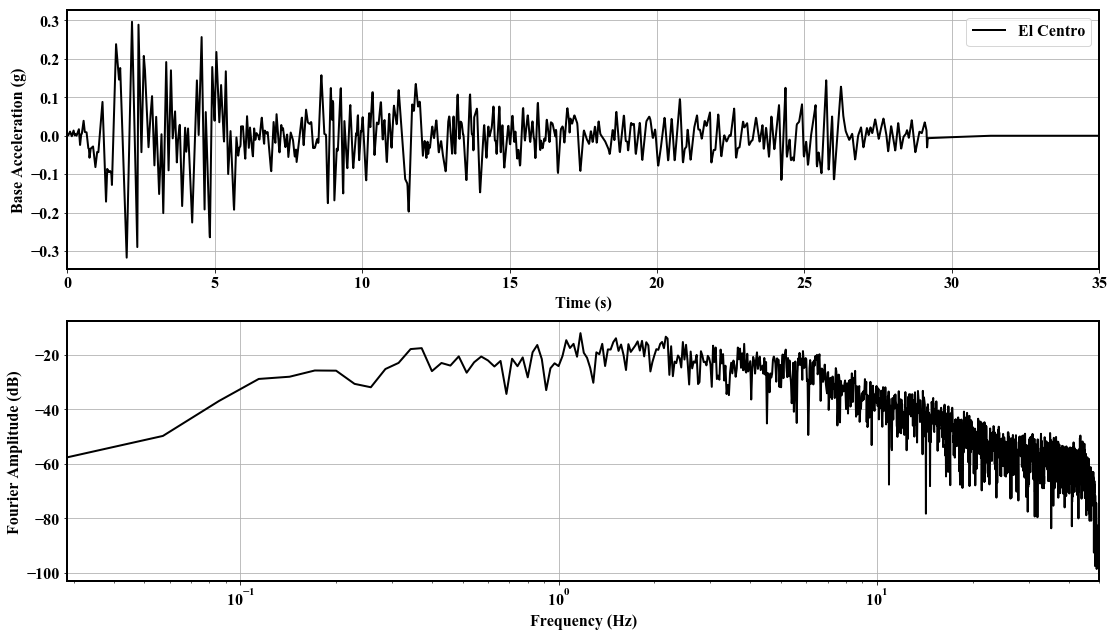

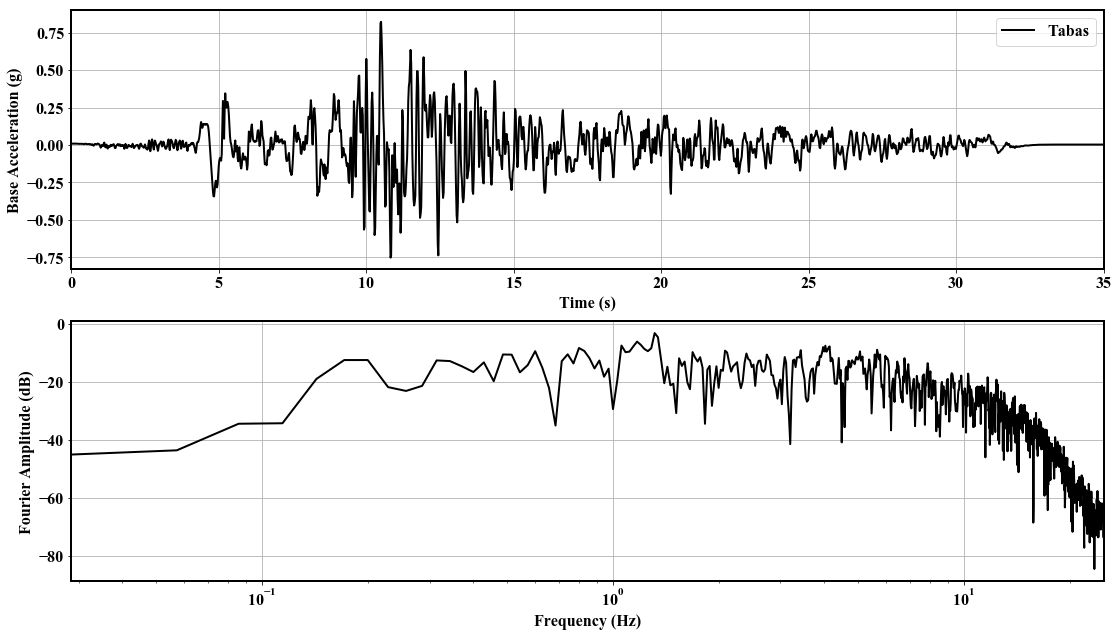

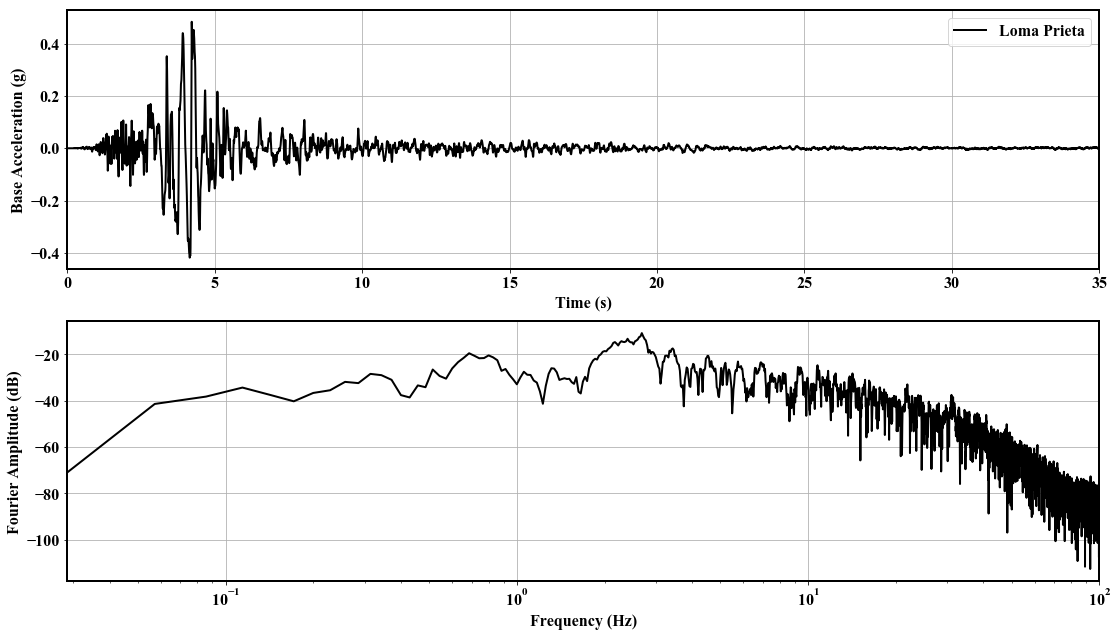

In [7]:
##earthquake analysis

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from math import *
from scipy.interpolate import interp1d
import pickle
from scipy.io import savemat

mpl.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 16
plt.rcParams['axes.linewidth'] = 2

def ddxg_el(Tf,dt):
    df = pd.read_excel (r'ELR.xlsx')
    baseacc=np.array(df)
    baseacc = np.insert(baseacc, 0, np.array([0,0.0063]), axis=0)
    NT=floor(Tf/dt)
    t=np.linspace(0,Tf,NT)
    new_acc = np.interp(t, baseacc[:,0], baseacc[:,1])*9.80665
    return new_acc

def ddxg_TABAS(Tf,dt):
    df = pd.read_excel (r'TABAS.xlsx')
    baseacc=np.array(df)
    baseacc = np.insert(baseacc, 0, np.array([0,0.009]), axis=0)
    NT=floor(Tf/dt)
    t=np.linspace(0,Tf,NT)
    new_acc = np.interp(t, baseacc[:,0], baseacc[:,1])*9.80665
    plt.plot(t,new_acc,c='black')
    return new_acc

def ddxg_Loma(Tf,dt):
    df = pd.read_excel (r'Loma.xlsx')
    baseacc=np.array(df)
    baseacc = np.insert(baseacc, 0, np.array([0,0]), axis=0)
    NT=floor(Tf/dt)
    t=np.linspace(0,Tf,NT)
    new_acc = np.interp(t, baseacc[:,0], baseacc[:,1])*9.80665
    plt.plot(t,new_acc,c='black')
    return new_acc



def FFT_Earthquake_El(Tf,dt):
    df = pd.read_excel (r'ELR.xlsx')
    baseacc=np.array(df)
    baseacc = np.insert(baseacc, 0, np.array([0,0.0063]), axis=0)
    NT=floor(Tf/dt)
    t=np.linspace(0,Tf,NT)
    new_acc = np.interp(t, baseacc[:,0], baseacc[:,1])#*9.80665
    yf = np.fft.fft(new_acc)*dt
    xf = np.fft.fftfreq(NT,dt)
    yf = np.fft.fftshift(yf)
    xf = np.fft.fftshift(xf)
    maxacc = max(abs(new_acc))
    U=interp1d(new_acc,t)
    if maxacc in new_acc:
        maxacc_time=U(maxacc)
    else :
        maxacc_time=U(-maxacc)
        maxacc =-maxacc
    fig,axs = plt.subplots(2,1)
    fig.set_size_inches(18.5, 10.5, forward=True)
    axs[0].plot(t,new_acc, c='black',linewidth=2)
    axs[0].set_xlim(0,max(t))
   # axs[0].axhline(y = 0, color = 'black', linestyle = '--')
    axs[0].set_ylabel('Base Acceleration (g)')
    axs[0].legend(['El Centro'])
    axs[0].set_xlabel("Time (s)")
    axs[0].grid()
   # axs[0].scatter(maxacc_time,maxacc,color = 'red')
   # axs[0].text(maxacc_time,maxacc,'  time : {0}\n  PGA : {1}  '.format(maxacc_time,abs(maxacc)))
    yf2= 20 * np.log10(np.abs(yf))
    axs[1].semilogx(xf, yf2, c='black',linewidth=2)    # [xf * 6.28] => for rad/s unit 
    axs[1].set_xlim(0,max(abs(xf)))
  #  plt.xscale('log')
  #  axs[1].set_ylim(bottom=0)
  #  axs[1].scatter(maxfreq,max(np.abs(yf)),color = 'red')
   # axs[1].text(maxfreq,max(np.abs(yf)),'  Freq : {0}\n  Fourier Amp: {1}  '.format((str(maxfreq)),max(np.abs(yf))),verticalalignment='top',fontsize=13)
    axs[1].set_ylabel("Fourier Amplitude (dB)")
    axs[1].grid()
    axs[1].set_xlabel('Frequency (Hz)')#r'Frequency $(\frac{rad}{s})$'
  #  plt.savefig('El Centro.svg', transparent=False, bbox_inches='tight')

    return t,new_acc,xf,yf

def FFT_Earthquake_TABAS(Tf,dt):
    df = pd.read_excel (r'TABAS.xlsx')
    baseacc=np.array(df)
    baseacc = np.insert(baseacc, 0, np.array([0,0.009]), axis=0)
    NT=floor(Tf/dt)
    t=np.linspace(0,Tf,NT)
    new_acc = np.interp(t, baseacc[:,0], baseacc[:,1])#*9.80665
    yf = np.fft.fft(new_acc)*dt #must be checked
    xf = np.fft.fftfreq(NT,dt)
    yf = np.fft.fftshift(yf)
    xf = np.fft.fftshift(xf)
    maxacc = max(abs(new_acc))
    U=interp1d(new_acc,t)
    if maxacc in new_acc:
        maxacc_time=U(maxacc)
    else :
        maxacc_time=U(-maxacc)
        maxacc =-maxacc
        
    maxacc_time=U(maxacc)
    fig,axs = plt.subplots(2,1)
    fig.set_size_inches(18.5, 10.5, forward=True)
    axs[0].plot(t,new_acc, c='black',linewidth=2)
    axs[0].set_xlim(0,max(t))
   # axs[0].axhline(y = 0, color = 'black', linestyle = '--')
    axs[0].set_ylabel('Base Acceleration (g)')
    axs[0].legend(['Tabas'])
    axs[0].set_xlabel("Time (s)")
    axs[0].grid()
   # axs[0].scatter(maxacc_time,maxacc,color = 'red')
   # axs[0].text(maxacc_time,maxacc,'  time : {0}\n  PGA : {1}  '.format(maxacc_time,abs(maxacc)))
    ind=np.where(np.abs(yf) == max(np.abs(yf)))
    maxfreq=abs(xf[ind[0][0]])
    yf2= 20 * np.log10(np.abs(yf))
    axs[1].semilogx(xf, yf2, c='black',linewidth=2)    # [xf * 6.28] => for rad/s unit 
    axs[1].set_xlim(0,max(abs(xf)))    
    #axs[1].set_ylim(bottom=0)
    #axs[1].scatter(maxfreq,max(np.abs(yf)),color = 'red')
    #axs[1].text(maxfreq,max(np.abs(yf)),'  Freq : {0}\n  Fourier Amp: {1}  '.format((str(maxfreq)),max(np.abs(yf))),verticalalignment='top',fontsize=13)
    axs[1].set_ylabel("Fourier Amplitude (dB)")
    axs[1].set_xlabel('Frequency (Hz)')#r'Frequency $(\frac{rad}{s})$'
    axs[1].grid()
   # plt.savefig('TABAS.svg', transparent=False, bbox_inches='tight')
    return t,new_acc,xf,yf

def FFT_Earthquake_Loma(Tf,dt):
    df = pd.read_excel (r'Loma.xlsx')
    baseacc=np.array(df)
    baseacc = np.insert(baseacc, 0, np.array([0,0]), axis=0)
    NT=floor(Tf/dt)
    t=np.linspace(0,Tf,NT)
    new_acc = np.interp(t, baseacc[:,0], baseacc[:,1])#*9.80665
    yf = np.fft.fft(new_acc)*dt #must be checked
    xf = np.fft.fftfreq(NT,dt)
    yf = np.fft.fftshift(yf)
    xf = np.fft.fftshift(xf)
    maxacc = max(abs(new_acc))
    U=interp1d(new_acc,t)
    if maxacc in new_acc:
        maxacc_time=U(maxacc)
    else :
        maxacc_time=U(-maxacc)
        maxacc =-maxacc
        
    maxacc_time=U(maxacc)
    fig,axs = plt.subplots(2,1)
    fig.set_size_inches(18.5, 10.5, forward=True)
    axs[0].plot(t,new_acc, c='black',linewidth=2)
    axs[0].set_xlim(0,max(t))
   # axs[0].axhline(y = 0, color = 'black', linestyle = '--')
    axs[0].set_ylabel('Base Acceleration (g)')
    axs[0].legend(['Loma Prieta'])
    axs[0].set_xlabel("Time (s)")
    axs[0].grid()
   # axs[0].scatter(maxacc_time,maxacc,color = 'red')
   # axs[0].text(maxacc_time,maxacc,'  time : {0}\n  PGA : {1}  '.format(maxacc_time,abs(maxacc)))
    ind=np.where(np.abs(yf) == max(np.abs(yf)))
    maxfreq=abs(xf[ind[0][0]])
    yf2= 20 * np.log10(abs(yf))
    axs[1].semilogx(xf, yf2, c='black',linewidth=2)    # [xf * 6.28] => for rad/s unit 
    axs[1].set_xlim(0,max(abs(xf)))    
 #   axs[1].set_ylim(bottom=0)
    axs[1].grid()
  #  axs[1].scatter(maxfreq,max(np.abs(yf)),color = 'red')
   # axs[1].text(maxfreq,max(np.abs(yf)),'  Freq : {0}\n  Fourier Amp: {1}  '.format((str(maxfreq)),max(np.abs(yf))),verticalalignment='top',fontsize=13)
    axs[1].set_ylabel("Fourier Amplitude (dB)")
    axs[1].set_xlabel('Frequency (Hz)')#r'Frequency $(\frac{rad}{s})$'
    #plt.savefig('Loma Prieta.svg', transparent=False, bbox_inches='tight')
    return t,new_acc,xf,yf



res1=FFT_Earthquake_El(35,0.01)
res2=FFT_Earthquake_TABAS(35,0.02)
res3=FFT_Earthquake_Loma(35,0.005)
#ind=np.where(np.abs(res[0]) == max(np.abs(res[0])))
#maxfreq=abs(res[1][ind[0][0]])
#math.atan2(res[0].imag,res[0].real) #computing phase 
#max(abs(res[0]))
#maxfreq
earthquake_results={
    't_el':res1[0],
    'el_acc':res1[1],
    'el_freq':res1[2],
    'el_four':res1[3],
    't_TAB':res2[0],
    'TAB_acc':res2[1],
    'TAB_freq':res2[2],
    'TAB_four':res2[3],
    't_Loma':res3[0],
    'Loma_acc':res3[1],
    'Loma_freq':res3[2],
    'Loma_four':res3[3]
}
Elcentro={
    'Elcentro':np.array([res1[0],res1[1]*9.80665])
}

Tabas={
    'Tabas':np.array([res2[0],res2[1]*9.80665])
}
Loma={
   'Loma':np.array([res3[0],res3[1]*9.80665]) 
}
np.shape(Loma)
#savemat("earthquake_results.mat",earthquake_results)
#savemat("Elcentro.mat",Elcentro)
#savemat("Tabas.mat",Tabas)
#savemat("Loma.mat",Loma)
max(abs(res1[1]))

In [120]:
pd.read_excel (r'Loma.xlsx')

,0,0.1
0,0.005,0.000
1,0.010,0.000
2,0.015,0.000
3,0.020,0.000
4,0.025,0.000
...,...,...
7992,39.965,0.001
7993,39.970,0.001
7994,39.975,0.001
7995,39.980,0.001


In [64]:
r's(t) = \mathcal{A}\/\sin(2 \omega t)'

's(t) = \\mathcal{A}\\/\\sin(2 \\omega t)'

In [29]:
yf

NameError: name 'yf' is not defined

In [1]:
60/6.28

9.55414012738853

In [10]:
np.log10(10)

1.0

5

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import floor
from scipy.io import savemat

def ddxg_TABAS(Tf,dt):
    df = pd.read_excel (r'TABAS.xlsx')
    baseacc=np.array(df)
    baseacc = np.insert(baseacc, 0, np.array([0,0.009]), axis=0)
    NT=floor(Tf/dt)
    t=np.linspace(0,Tf,NT)
    new_acc = np.interp(t, baseacc[:,0], baseacc[:,1])*9.80665
    t=np.linspace(0,Tf,NT)
    plt.plot(t,new_acc,c='black')
    

ddxg_TABAS(40,0.01)

/opt/sagemath-9.1/local/lib/python3.7/site-packages/scipy/linalg/__init__.py:212: DeprecationWarning: The module numpy.dual is deprecated.  Instead of using dual, use the functions directly from numpy or scipy.
  from numpy.dual import register_func
/opt/sagemath-9.1/local/lib/python3.7/site-packages/scipy/special/orthogonal.py:81: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  from numpy import (exp, inf, pi, sqrt, floor, sin, cos, around, int,
/opt/sagemath-9.1/local/lib/python3.7/site-packages/scipy/sparse/sputils.py:23: DeprecationWarning: `np

In [89]:
df=pd.read_excel (r'TABAS.xlsx')
df.size/2


1649.0

In [79]:
np.array(df)

array([[2.000e-02, 9.000e-03],
       [4.000e-02, 9.000e-03],
       [6.000e-02, 1.000e-02],
       ...,
       [3.294e+01, 3.000e-03],
       [3.296e+01, 3.000e-03],
       [3.298e+01, 3.000e-03]])

In [30]:
import math
10*math.log(34.45645491201323,10)
math.ata


15.372705925737016

In [ ]:
atan2

In [133]:
(2*3.14)/(60*(1.3250000000000002))

0.0789937106918239

In [18]:
6.617889260330444/2

3.30894463016522

In [3]:
import matplotlib.font_manager as fm# Collect all the font names available to matplotlib
font_names = [f.name for f in fm.fontManager.ttflist]
print(font_names)

['cmsy10', 'DejaVu Serif', 'cmb10', 'STIXSizeFiveSym', 'STIXNonUnicode', 'DejaVu Sans Mono', 'STIXSizeOneSym', 'STIXSizeOneSym', 'STIXSizeTwoSym', 'STIXSizeTwoSym', 'cmtt10', 'STIXGeneral', 'STIXNonUnicode', 'cmss10', 'DejaVu Serif', 'STIXGeneral', 'DejaVu Sans', 'DejaVu Serif', 'DejaVu Sans', 'STIXSizeFourSym', 'DejaVu Serif', 'STIXGeneral', 'STIXGeneral', 'cmmi10', 'STIXNonUnicode', 'STIXSizeFourSym', 'DejaVu Sans Mono', 'DejaVu Sans Mono', 'cmex10', 'DejaVu Serif Display', 'DejaVu Sans Display', 'cmr10', 'DejaVu Sans', 'STIXNonUnicode', 'STIXSizeThreeSym', 'DejaVu Sans Mono', 'STIXSizeThreeSym', 'DejaVu Sans', 'Cambria', 'Courier New', 'Consolas', 'Segoe MDL2 Assets', 'Constantia', 'Nimbus Sans', 'Nimbus Sans', 'Cambria', 'Candara', 'Gadugi', 'Malgun Gothic', 'Nirmala UI', 'Microsoft PhagsPa', 'Myanmar Text', 'P052', 'Leelawadee UI', 'Nimbus Sans Narrow', 'Segoe UI', 'Microsoft Tai Le', 'Gadugi', 'Segoe UI', 'URW Gothic', 'Courier New', 'DejaVu Sans', 'Candara', 'Arial', 'Ink Free',

In [7]:
print(int(5.3258 * (10**2))/(10**2))

133/25


In [4]:
x, y = var('x,y')
f(x,y) = x**2 + y**2
from sage.misc.latex import MathJax
mj = MathJax()
html(mj.eval(latex(f)))

<html><script type="math/tex; mode=display">\newcommand{\Bold}[1]{\mathbf{#1}}\left( x, y \right) \ {\mapsto} \ x^{2} + y^{2}</script></html>

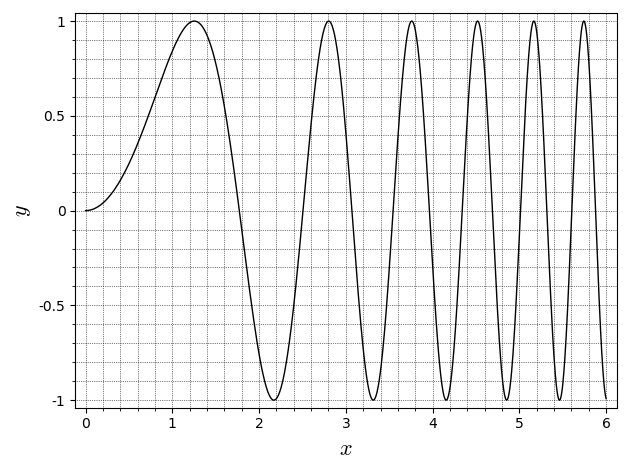

In [1]:
g1 = plot(sin(x^2), (x, 0, 6), axes_labels=['$x$', '$y$'],
          axes=False,frame=True, gridlines='minor',color='black')
g1.show()

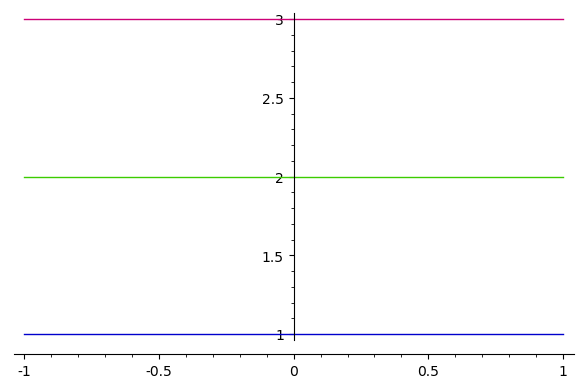

Text(0,0.5,'$y$')

/opt/sagemath-9.1/local/lib/python3.7/site-packages/matplotlib/font_manager.py:1333: UserWarning: findfont: Font family ['Time New Roman'] not found. Falling back to DejaVu Sans
  (prop.get_family(), self.defaultFamily[fontext]))


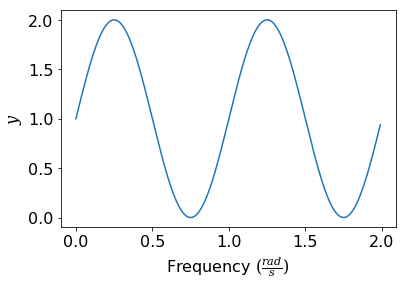

In [64]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
plt.rcParams["mathtext.fontset"]='dejavuserif'
mpl.rcParams['font.family'] = 'Time New Roman'
plt.rcParams['font.size'] = 16

t = np.arange(0.0, 2.0, 0.01)
s = 1 + np.sin(2 * np.pi * t)
plt.plot(t,s)
plt.xlabel(r'Frequency $(\frac{rad}{s})$')
plt.ylabel('$y$')
#list_plot(t,s)

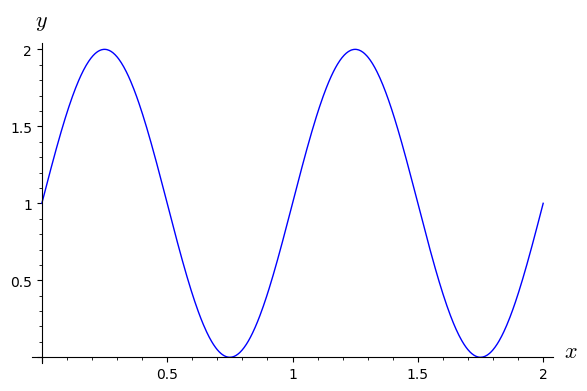

In [25]:
t = np.arange(0.0, 2.0, 0.01)
s = 1 + np.sin(2 * np.pi * t)
plot(1 + np.sin(2 * np.pi * x),(x,0,2),axes_labels=['$x$', '$y$'])

In [30]:
valid strings are ['dejavusans', 'dejavuserif', 'cm', 'stix', 'stixsans', 'custom'

SyntaxError: invalid syntax (<ipython-input-30-e68b07831439>, line 1)